<a href="https://colab.research.google.com/github/Basurero2/-Estadistica-con-Python-frecuencias-y-medidas/blob/juan-carlos/hackathon_dataset_avanzado_documentado_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Documentación del notebook

Este notebook desarrolla un flujo de trabajo para un proyecto de salud financiera basado en transacciones y datos de clientes. El proceso parte de dos fuentes principales: un conjunto de **transacciones** y un conjunto de **clientes**. Posteriormente se limpian y preparan los datos, se construyen variables financieras, se realiza un análisis exploratorio y se entrenan modelos para dos tareas:

1. Clasificar transacciones según su categoría de gasto.
2. Clasificar clientes según su perfil financiero.

Finalmente se realizan pruebas con datos nuevos y se utiliza SHAP para interpretar el modelo de perfil financiero.

> **Criterio de documentación:** las explicaciones de este notebook describen el código tal como está escrito. No se modifican, corrigen ni sustituyen las operaciones originales.

### Importación de librerías

En esta sección se cargan las bibliotecas utilizadas durante el análisis. `pandas` se emplea para la manipulación de datos; `rapidfuzz` para comparación aproximada de textos; y `seaborn` y `matplotlib` para las visualizaciones.

También se instala `rapidfuzz` dentro del entorno de ejecución mediante `pip`.

Por último, se utiliza `warnings` para suprimir advertencias.

In [65]:
import pandas as pd
!pip install rapidfuzz
from rapidfuzz import process, fuzz
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')


## 1. Transacciones: limpieza y revisión de datos

Esta sección prepara el conjunto de datos de transacciones. Primero se carga el archivo, se revisa su estructura y contenido, se verifican las categorías disponibles y se realizan transformaciones destinadas a dejar una tabla de transacciones utilizable en las etapas posteriores.

### Carga del conjunto de transacciones

Se lee el archivo `transactions.csv` desde la ruta utilizada por Google Colab y se almacena en el objeto `transacciones`.

In [66]:
# asignando una variable al dataset
transacciones = pd.read_csv('/content/transactions.csv')

### Revisión de la estructura

`info()` permite comprobar el número de registros, columnas, tipos de datos y presencia de valores no nulos. En la ejecución mostrada, el conjunto contiene **125,465 registros y 13 columnas**.

In [67]:
# revisando brevemente las columnas
transacciones.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119465 entries, 0 to 119464
Data columns (total 13 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   transaction_id           119465 non-null  int64  
 1   user_id                  119465 non-null  int64  
 2   fecha_transaccion        119465 non-null  object 
 3   descripcion_transaccion  119465 non-null  object 
 4   monto_transaccion        119465 non-null  float64
 5   medio_pago               119465 non-null  object 
 6   edad                     119465 non-null  int64  
 7   sexo                     119465 non-null  object 
 8   ingreso_mensual          119465 non-null  int64  
 9   linea_credito            119465 non-null  int64  
 10  credito_utilizado        119465 non-null  int64  
 11  frecuencia_ahorro        119465 non-null  object 
 12  categoria_gasto          119465 non-null  object 
dtypes: float64(1), int64(6), object(6)
memory usage: 11.8+ MB


### Revisión del contenido

Se muestran las primeras cinco observaciones para comprobar visualmente cómo están representadas las transacciones y sus variables principales, como comercio, monto, medio de pago, datos del usuario y categoría de gasto.

In [68]:
# revisando brevemente el contenido
transacciones.head(5)

,transaction_id,user_id,fecha_transaccion,descripcion_transaccion,monto_transaccion,medio_pago,edad,sexo,ingreso_mensual,linea_credito,credito_utilizado,frecuencia_ahorro,categoria_gasto
0,1,1,2025-10-30,Soriana,1072.15,Debito,58,M,37256,30000,24132,Baja,Alimentacion
1,2,1,2025-04-22,Soriana,604.67,Debito,58,M,37256,30000,24132,Baja,Alimentacion
2,3,1,2025-04-12,Farmacias del Ahorro,1798.57,Transferencia,58,M,37256,30000,24132,Baja,Salud
3,4,1,2025-08-18,Uber,1485.49,Debito,58,M,37256,30000,24132,Baja,Transporte
4,5,1,2025-12-24,OXXO,1073.86,Efectivo,58,M,37256,30000,24132,Baja,Alimentacion


### Revisión de las categorías de gasto

Se consulta la lista de valores únicos de `categoria_gasto`. La salida muestra las ocho categorías contempladas en el desafío: Alimentacion, Salud, Transporte, Compras, Servicios, Entretenimiento, Vivienda y Educacion.

La segunda impresión de esta celda conserva el mensaje escrito originalmente en el notebook.

In [69]:
# Revisando las categorías en 'categoria_gasto'
print (transacciones['categoria_gasto'].unique())
print (f'Se encuentran ausentes dos categorías: "Vivienda y Educación')

['Alimentacion' 'Salud' 'Transporte' 'Compras' 'Servicios'
 'Entretenimiento']
Se encuentran ausentes dos categorías: "Vivienda y Educación


### Incorporación de categorías de Vivienda y Educación

Se generan dos transacciones adicionales por usuario: una para `Vivienda` y otra para `Educacion`. Los demás atributos del usuario se toman de su primera observación y algunos atributos de la transacción se generan aleatoriamente.

Después se concatenan las nuevas filas al conjunto original y se vuelve a numerar `transaction_id`. La ejecución registrada indica que se añadieron **6,000 filas**, correspondientes a dos nuevas transacciones para cada uno de los 3,000 usuarios.

In [70]:
# Añadiendo las categorías que faltaban de acuerdo con el desafío (educación y vivienda)

import numpy as np
import random

# Obtener todos los IDs de usuario únicos
unique_users = transacciones['user_id'].unique()

new_rows = []

for user in unique_users:
    # Datos base del usuario (asumiendo que edad, sexo, ingreso, etc. son constantes por usuario)
    user_info = transacciones[transacciones['user_id'] == user].iloc[0]

    # 1. Transacción de Vivienda
    new_rows.append({
        'transaction_id': 0, # Se resetearán después
        'user_id': user,
        'fecha_transaccion': '2025-06-15',
        'descripcion_transaccion': random.choice(['Home Depot', 'Interceramic']),
        'monto_transaccion': round(random.uniform(500, 5000), 2),
        'medio_pago': random.choice(['Debito', 'Credito', 'Transferencia']),
        'edad': user_info['edad'],
        'sexo': user_info['sexo'],
        'ingreso_mensual': user_info['ingreso_mensual'],
        'linea_credito': user_info['linea_credito'],
        'credito_utilizado': user_info['credito_utilizado'],
        'frecuencia_ahorro': user_info['frecuencia_ahorro'],
        'categoria_gasto': 'Vivienda'
    })

    # 2. Transacción de Educación
    new_rows.append({
        'transaction_id': 0,
        'user_id': user,
        'fecha_transaccion': '2025-07-20',
        'descripcion_transaccion': random.choice(['Librerías Gandhi', 'Proveedora Escolar']),
        'monto_transaccion': round(random.uniform(200, 1500), 2),
        'medio_pago': random.choice(['Debito', 'Credito', 'Efectivo']),
        'edad': user_info['edad'],
        'sexo': user_info['sexo'],
        'ingreso_mensual': user_info['ingreso_mensual'],
        'linea_credito': user_info['linea_credito'],
        'credito_utilizado': user_info['credito_utilizado'],
        'frecuencia_ahorro': user_info['frecuencia_ahorro'],
        'categoria_gasto': 'Educacion'
    })

# Crear DataFrame con nuevas filas y concatenar
df_nuevos = pd.DataFrame(new_rows)
transacciones = pd.concat([transacciones, df_nuevos], ignore_index=True)

# Recalcular transaction_id para que sea único
transacciones['transaction_id'] = range(1, len(transacciones) + 1)

print(f'Se añadieron {len(df_nuevos)} nuevas filas.')
display(transacciones.tail(3))

Se añadieron 6000 nuevas filas.


,transaction_id,user_id,fecha_transaccion,descripcion_transaccion,monto_transaccion,medio_pago,edad,sexo,ingreso_mensual,linea_credito,credito_utilizado,frecuencia_ahorro,categoria_gasto
125462,125463,2999,2025-07-20,Librerías Gandhi,213.22,Debito,54,M,41035,30000,23407,Alta,Educacion
125463,125464,3000,2025-06-15,Interceramic,4173.93,Credito,46,F,58563,30000,13664,Media,Vivienda
125464,125465,3000,2025-07-20,Proveedora Escolar,512.52,Efectivo,46,F,58563,30000,13664,Media,Educacion


### Verificación de las categorías

Se vuelve a consultar `categoria_gasto` para comprobar que las ocho categorías se encuentran presentes después de la incorporación de las nuevas observaciones.

In [71]:
# ya aparecen las categorías que faltaban en el set original

print (transacciones['categoria_gasto'].unique())
print (f'Ya se encuentran las 8 categorías')

['Alimentacion' 'Salud' 'Transporte' 'Compras' 'Servicios'
 'Entretenimiento' 'Vivienda' 'Educacion']
Ya se encuentran las 8 categorías


### Selección de variables para el conjunto de transacciones

Se crea `transacciones_ok` eliminando las variables `edad`, `sexo`, `ingreso_mensual`, `linea_credito`, `credito_utilizado` y `frecuencia_ahorro`.

A partir de este punto, el objeto `transacciones_ok` conserva las variables consideradas necesarias para el tratamiento específico de las transacciones.

In [72]:
# Eliminando las variables que no sirven para este dataset

transacciones_ok = transacciones.drop(['edad', 'sexo', 'ingreso_mensual', 'linea_credito', 'credito_utilizado', 'frecuencia_ahorro'], axis = 1)

### Normalización de texto

Se identifican las columnas de tipo texto y se convierten sus valores a minúsculas. Esto busca homogeneizar la representación textual de comercios, medios de pago y categorías antes de las operaciones posteriores de comparación y modelado.

In [73]:
# Pasando todo el texto a minúsculas

text_columns = transacciones_ok.select_dtypes(include=['object']).columns

for col in text_columns:
    transacciones_ok[col] = transacciones_ok[col].str.lower()

display(transacciones_ok.head())

,transaction_id,user_id,fecha_transaccion,descripcion_transaccion,monto_transaccion,medio_pago,categoria_gasto
0,1,1,2025-10-30,soriana,1072.15,debito,alimentacion
1,2,1,2025-04-22,soriana,604.67,debito,alimentacion
2,3,1,2025-04-12,farmacias del ahorro,1798.57,transferencia,salud
3,4,1,2025-08-18,uber,1485.49,debito,transporte
4,5,1,2025-12-24,oxxo,1073.86,efectivo,alimentacion


### Renombrado de la variable del comercio

La columna `descripcion_transaccion` se renombra como `nombre_comercio`, haciendo explícito que su contenido representa el nombre o descripción del comercio asociado con la transacción.

In [74]:
transacciones_ok.columns = transacciones_ok.columns.str.replace("descripcion_transaccion","nombre_comercio")

### Verificación de nombres de columnas

Se muestran las columnas de `transacciones_ok` después del renombrado para confirmar la estructura resultante.

In [75]:
transacciones_ok.columns

Index(['transaction_id', 'user_id', 'fecha_transaccion', 'nombre_comercio',
       'monto_transaccion', 'medio_pago', 'categoria_gasto'],
      dtype='object')

### Ajuste del monto de transacción

El monto de cada transacción se divide entre `1.3`. Esta operación modifica la escala de `monto_transaccion` antes de las etapas de análisis y modelado posteriores.

In [76]:
transacciones_ok['monto_transaccion'] = transacciones_ok['monto_transaccion'] / 1.3

### Revisión posterior de la estructura

Se vuelve a ejecutar `info()` sobre `transacciones_ok` para revisar la estructura del conjunto después de las transformaciones anteriores.

In [77]:
transacciones_ok.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125465 entries, 0 to 125464
Data columns (total 7 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   transaction_id     125465 non-null  int64  
 1   user_id            125465 non-null  int64  
 2   fecha_transaccion  125465 non-null  object 
 3   nombre_comercio    125465 non-null  object 
 4   monto_transaccion  125465 non-null  float64
 5   medio_pago         125465 non-null  object 
 6   categoria_gasto    125465 non-null  object 
dtypes: float64(1), int64(2), object(4)
memory usage: 6.7+ MB


### Comprobación de valores nulos

Se contabilizan los valores ausentes por columna mediante `isnull().sum()`. Esta comprobación permite verificar la existencia de datos faltantes antes de continuar con el análisis.

In [78]:
transacciones_ok.isnull().sum()

,0
transaction_id,0
user_id,0
fecha_transaccion,0
nombre_comercio,0
monto_transaccion,0
medio_pago,0
categoria_gasto,0


### Comprobación de duplicados

Se calcula el número de filas duplicadas mediante `duplicated().sum()`. El resultado se utiliza para verificar la duplicación exacta de registros.

In [79]:
transacciones_ok.duplicated().sum()

np.int64(0)

### Resultado de la revisión inicial

El notebook registra que no existen datos nulos, duplicados, textos en mayúsculas ni categorías faltantes en el conjunto preparado hasta este punto.

### Inspección de las transacciones preparadas

Se muestran las primeras diez filas de `transacciones_ok` para comprobar visualmente el resultado de la limpieza y transformación.

In [80]:
transacciones_ok.head(10)

,transaction_id,user_id,fecha_transaccion,nombre_comercio,monto_transaccion,medio_pago,categoria_gasto
0,1,1,2025-10-30,soriana,824.730769,debito,alimentacion
1,2,1,2025-04-22,soriana,465.130769,debito,alimentacion
2,3,1,2025-04-12,farmacias del ahorro,1383.515385,transferencia,salud
3,4,1,2025-08-18,uber,1142.684615,debito,transporte
4,5,1,2025-12-24,oxxo,826.046154,efectivo,alimentacion
5,6,1,2025-04-21,oxxo,1841.784615,efectivo,alimentacion
6,7,1,2025-02-17,soriana,744.938462,efectivo,alimentacion
7,8,1,2025-11-06,pemex,525.669231,debito,transporte
8,9,1,2025-08-24,amazon,1041.907692,transferencia,compras
9,10,1,2025-10-10,soriana,580.115385,efectivo,alimentacion


### Exportación del conjunto de transacciones

Se guarda `transacciones_ok` en el archivo `transacciones_ok.csv`, sin incluir el índice del DataFrame.

In [81]:
transacciones_ok.to_csv('transacciones_ok.csv', index=False)

## 2. Entrenamiento de categorías

Esta sección construye los insumos para categorizar comercios. Se extraen las relaciones comercio-categoría observadas en las transacciones y se combinan con un inventario de comercios mexicanos utilizado como catálogo de referencia y como conjunto de entrenamiento para un clasificador textual.

### Construcción de pares únicos comercio-categoría

Se seleccionan `nombre_comercio` y `categoria_gasto` de las transacciones y se eliminan duplicados. Después se renombran las columnas como `comercio` y `categoria` para hacerlas compatibles con el inventario utilizado posteriormente.

In [82]:
negocios_unicos = transacciones_ok[["nombre_comercio", "categoria_gasto"]].drop_duplicates()
negocios_unicos.columns = ["comercio","categoria"]

### Carga del inventario de comercios

Se carga el archivo `inventario_comercios_mexicanos_800_variado.csv` en el DataFrame `comercios`. Este archivo constituye el catálogo utilizado en la etapa de categorización.

In [83]:
comercios = pd.read_csv('/content/inventario_comercios_mexicanos_800_variado.csv')


### Integración del inventario con comercios observados

Se concatenan el inventario de comercios y los pares únicos derivados de las transacciones para construir `comercios_actualizado`.

In [84]:
comercios_actualizado = pd.concat([comercios, negocios_unicos],ignore_index=True)

### Eliminación de comercios duplicados

Se eliminan duplicados de `comercios_actualizado` tomando `comercio` como identificador y conservando la primera aparición. También se imprimen las dimensiones del inventario original y del conjunto actualizado para observar el cambio de tamaño.

In [85]:
comercios_actualizado = comercios_actualizado.drop_duplicates(subset=["comercio"],keep="first")
print(comercios.shape)
print(comercios_actualizado.shape)

(800, 2)
(811, 2)


### Entrenamiento de un modelo de clasificación textual

Se construye un `Pipeline` con `TfidfVectorizer` para transformar los nombres de comercios en representación numérica y `LogisticRegression` como clasificador.

El modelo se entrena utilizando `comercios['comercio']` como variable de entrada y `comercios['categoria']` como variable objetivo.

In [86]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

X = comercios["comercio"]
y = comercios["categoria"]

modelo = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("clf", LogisticRegression())
])

modelo.fit(X, y)

Pipeline(steps=[('tfidf', TfidfVectorizer()), ('clf', LogisticRegression())])

### Categorización mediante coincidencia aproximada o modelo

Se crea una lista con los nombres del catálogo y una función que primero busca una coincidencia textual mediante `rapidfuzz` y `token_sort_ratio`.

Si la similitud alcanza al menos **90 puntos**, se utiliza la categoría asociada al comercio encontrado en el catálogo. Si no se alcanza ese umbral, se utiliza el modelo de regresión logística para predecir la categoría.

In [87]:
lista_comercios = comercios["comercio"].tolist()
def categorizar_comercio(texto):
    comercio, score, _ = process.extractOne(
        texto.upper(),
        lista_comercios,
        scorer=fuzz.token_sort_ratio
    )
    # Si encontró un comercio con alta confianza
    if score >= 90:
        categoria = comercios.loc[
            comercios["comercio"] == comercio,
            "categoria"
        ].iloc[0]
        return {
            "metodo": "catalogo",
            "comercio": comercio,
            "score": score,
            "categoria": categoria
        }
    # Si no encontró comercio confiable
    categoria_predicha = modelo.predict([texto])[0]
    return {
        "metodo": "modelo",
        "comercio": None,
        "score": score,
        "categoria": categoria_predicha
    }

### Redefinición de la función de categorización

La función `categorizar_comercio` se redefine. Mantiene la estrategia de coincidencia aproximada con umbral de 90 y, cuando no encuentra una coincidencia suficiente, utiliza el modelo textual y calcula además la probabilidad máxima de las categorías.

Cuando la confianza máxima es inferior a 60 %, la predicción se asigna a `otros servicios`. La función redefinida devuelve la categoría bajo la clave `nombre_comercio`.

In [88]:
def categorizar_comercio(texto):
    comercio, score, _ = process.extractOne(
        texto.upper(),
        lista_comercios,
        scorer=fuzz.token_sort_ratio
    )
    if score >= 90:
        categoria = comercios.loc[
            comercios["comercio"] == comercio,
            "categoria"
        ].iloc[0]
        return {
            "categoria": categoria
        }
    categoria_predicha = modelo.predict([texto])[0]
    probabilidades = modelo.predict_proba([texto])[0]
    confianza = max(probabilidades)
    if confianza < 60:
        categoria_predicha = "otros servicios"
    return {
        "nombre_comercio": categoria_predicha
    }

### Prueba de categorización

Se ejecuta la función con el comercio de prueba `aguaje sac` para observar la categoría que produce el procedimiento de categorización.

In [89]:
categorizar_comercio("aguaje sac")

{'nombre_comercio': 'otros servicios'}

## 3. Clientes: limpieza y revisión de datos

Esta sección prepara la información de los clientes que posteriormente se combinará con las transacciones para construir indicadores financieros y perfiles financieros.

### Carga del conjunto de clientes

Se lee el archivo `users.csv` y se almacena en `clientes`. También se muestran las primeras tres observaciones para realizar una inspección inicial.

In [90]:
clientes = pd.read_csv('/content/users.csv')
clientes.head(3)

,user_id,edad,sexo,estado_civil,numero_hijos,empleo_formal,ingreso_mensual,linea_credito,credito_utilizado,frecuencia_ahorro,monto_promedio_ahorro,perfil_financiero
0,1,58,M,Soltero,2,0,37256,30000,24132,Baja,1117.68,En riesgo
1,2,31,M,Divorciado,1,1,61354,30000,3090,Baja,1840.62,En observacion
2,3,29,F,Divorciado,1,1,28866,15000,6267,Alta,6350.52,En observacion


### Revisión de la estructura de clientes

`info()` permite revisar dimensiones, tipos de datos y valores no nulos del conjunto de clientes.

In [91]:
clientes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   user_id                3000 non-null   int64  
 1   edad                   3000 non-null   int64  
 2   sexo                   3000 non-null   object 
 3   estado_civil           3000 non-null   object 
 4   numero_hijos           3000 non-null   int64  
 5   empleo_formal          3000 non-null   int64  
 6   ingreso_mensual        3000 non-null   int64  
 7   linea_credito          3000 non-null   int64  
 8   credito_utilizado      3000 non-null   int64  
 9   frecuencia_ahorro      3000 non-null   object 
 10  monto_promedio_ahorro  3000 non-null   float64
 11  perfil_financiero      3000 non-null   object 
dtypes: float64(1), int64(7), object(4)
memory usage: 281.4+ KB


### Revisión de columnas

Se muestran los nombres de las columnas disponibles en el DataFrame `clientes`.

In [92]:
clientes.columns

Index(['user_id', 'edad', 'sexo', 'estado_civil', 'numero_hijos',
       'empleo_formal', 'ingreso_mensual', 'linea_credito',
       'credito_utilizado', 'frecuencia_ahorro', 'monto_promedio_ahorro',
       'perfil_financiero'],
      dtype='object')

### Comparación de estructuras

Se imprimen las columnas de `transacciones_ok` y `clientes` para identificar las variables disponibles en ambos conjuntos antes de realizar operaciones de integración.

In [93]:
print (f'Las columnas de transacciones son {transacciones_ok.columns}')
print (f'Las columnas de clientes son {clientes.columns}')

Las columnas de transacciones son Index(['transaction_id', 'user_id', 'fecha_transaccion', 'nombre_comercio',
       'monto_transaccion', 'medio_pago', 'categoria_gasto'],
      dtype='object')
Las columnas de clientes son Index(['user_id', 'edad', 'sexo', 'estado_civil', 'numero_hijos',
       'empleo_formal', 'ingreso_mensual', 'linea_credito',
       'credito_utilizado', 'frecuencia_ahorro', 'monto_promedio_ahorro',
       'perfil_financiero'],
      dtype='object')


### Normalización de texto en clientes

Se identifican las columnas de texto del conjunto de clientes y sus valores se convierten a minúsculas. Finalmente se muestran algunas observaciones para comprobar el resultado.

In [94]:
text_columns_clientes = clientes.select_dtypes(include=['object']).columns

for col in text_columns_clientes:
    clientes[col] = clientes[col].str.lower()

display(clientes.head())

,user_id,edad,sexo,estado_civil,numero_hijos,empleo_formal,ingreso_mensual,linea_credito,credito_utilizado,frecuencia_ahorro,monto_promedio_ahorro,perfil_financiero
0,1,58,m,soltero,2,0,37256,30000,24132,baja,1117.68,en riesgo
1,2,31,m,divorciado,1,1,61354,30000,3090,baja,1840.62,en observacion
2,3,29,f,divorciado,1,1,28866,15000,6267,alta,6350.52,en observacion
3,4,19,f,unión libre,3,0,69261,30000,20390,media,6926.10,en riesgo
4,5,62,m,divorciado,0,0,45268,80000,62746,media,4526.80,en riesgo


### Comprobación de valores nulos en clientes

Se contabilizan los valores ausentes de cada columna del conjunto `clientes`.

In [95]:
clientes.isnull().sum()

,0
user_id,0
edad,0
sexo,0
estado_civil,0
numero_hijos,0
empleo_formal,0
ingreso_mensual,0
linea_credito,0
credito_utilizado,0
frecuencia_ahorro,0


### Comprobación de duplicados en clientes

Se calcula el número de registros duplicados dentro del DataFrame `clientes`.

In [96]:
clientes.duplicated().sum()

np.int64(0)

### Resultado de la revisión de clientes

El notebook registra que no existen valores nulos ni duplicados en el dataset de clientes.

### Eliminación de variables no utilizadas

Se eliminan de `clientes` las columnas `credito_utilizado`, `frecuencia_ahorro`, `monto_promedio_ahorro` y `perfil_financiero`. La estructura resultante se utilizará para calcular nuevamente las variables financieras y el perfil financiero en las siguientes etapas.

In [97]:
# Eliminando las variables que no sirven para este dataset

clientes = clientes.drop(['credito_utilizado', 'frecuencia_ahorro', 'monto_promedio_ahorro','perfil_financiero'], axis = 1)

### Inspección del conjunto de clientes

Se muestran las primeras diez observaciones del DataFrame `clientes` después de la eliminación de variables.

In [98]:
clientes.head(10)

,user_id,edad,sexo,estado_civil,numero_hijos,empleo_formal,ingreso_mensual,linea_credito
0,1,58,m,soltero,2,0,37256,30000
1,2,31,m,divorciado,1,1,61354,30000
2,3,29,f,divorciado,1,1,28866,15000
3,4,19,f,unión libre,3,0,69261,30000
4,5,62,m,divorciado,0,0,45268,80000
5,6,35,m,unión libre,3,1,23915,15000
6,7,58,f,unión libre,3,1,34111,80000
7,8,50,m,divorciado,4,0,13683,120000
8,9,49,f,divorciado,2,0,75154,15000
9,10,36,f,casado,2,0,26537,50000


### Exportación de clientes preparados

Se guarda el conjunto preparado como `users_ok.csv`, sin incluir el índice del DataFrame.

In [99]:
clientes.to_csv('users_ok.csv', index=False)

## 4. Cálculo de variables financieras

En esta sección se construyen indicadores derivados de las transacciones y de la información de los clientes. Los cálculos generan `gasto_total`, `nivel_endeudamiento`, `rango_ahorro` y, posteriormente, `perfil_financiero`.

### Gasto total y nivel de endeudamiento

Primero se suma `monto_transaccion` por `user_id` para obtener `gasto_total`. Ese resultado se integra al DataFrame de clientes.

Después se calcula `nivel_endeudamiento` como:

`gasto_total / (ingreso_mensual + linea_credito)`

Los valores infinitos o ausentes se sustituyen por cero y el resultado se redondea a dos decimales.

In [100]:
# ==================================
# Gasto total por usuario
# ==================================

gasto_total = (transacciones_ok.groupby("user_id")["monto_transaccion"].sum().reset_index(name="gasto_total"))

# ==================================
# Unir con clientes
# ==================================

clientes = clientes.merge(gasto_total, on="user_id", how="left")

clientes["gasto_total"] = ( clientes["gasto_total"] .fillna(0))

# ==================================
# Capacidad financiera
# ==================================

clientes["nivel_endeudamiento"] = (clientes["gasto_total"] / ( clientes["ingreso_mensual"] + clientes["linea_credito"]))

clientes["nivel_endeudamiento"] = (
    clientes["nivel_endeudamiento"]
    .replace([np.inf, -np.inf], 0)
    .fillna(0)
    .round(2)
)


### Revisión de las variables financieras

Se muestran las últimas cinco observaciones de `clientes` para revisar los valores recién calculados.

In [101]:
clientes.tail(5)

,user_id,edad,sexo,estado_civil,numero_hijos,empleo_formal,ingreso_mensual,linea_credito,gasto_total,nivel_endeudamiento
2995,2996,37,f,soltero,2,0,14554,30000,39411.030769,0.88
2996,2997,31,m,soltero,4,1,39930,30000,37736.115385,0.54
2997,2998,52,m,casado,2,1,76397,30000,33325.761538,0.31
2998,2999,54,m,unión libre,4,0,41035,30000,51560.046154,0.73
2999,3000,46,f,soltero,0,1,58563,30000,31920.623077,0.36


### Cálculo del rango de ahorro

`rango_ahorro` se calcula como la proporción del ingreso mensual que permanece después de restar el gasto total:

`(ingreso_mensual - gasto_total) / ingreso_mensual`

El numerador se limita a valores no negativos mediante `clip(lower=0)`. Posteriormente se controlan infinitos y valores ausentes y se redondea el resultado a dos decimales.

In [102]:
# ==================================
# Porcentaje de ahorro
# ==================================

clientes["rango_ahorro"] = (
    (
        clientes["ingreso_mensual"]
        - clientes["gasto_total"]
    ).clip(lower=0)
    / clientes["ingreso_mensual"]
)

clientes["rango_ahorro"] = (
    clientes["rango_ahorro"]
    .replace([np.inf, -np.inf], 0)
    .fillna(0)
    .round(2)
)

### Construcción del perfil financiero

Se define una función que clasifica a cada cliente utilizando dos indicadores: `nivel_endeudamiento` y `rango_ahorro`.

- **SALUDABLE:** endeudamiento menor o igual a 0.50 y ahorro mayor o igual a 0.20.
- **MODERADO:** endeudamiento menor o igual a 0.80 y ahorro mayor o igual a 0.10.
- **RIESGOSO:** cualquier combinación que no cumpla las condiciones anteriores.

La función se aplica fila por fila y el resultado se almacena en `perfil_financiero`.

In [103]:
def calcular_perfil_financiero(row):

    deuda = row["nivel_endeudamiento"]
    ahorro = row["rango_ahorro"]

    if deuda <= 0.50 and ahorro >= 0.20:
        return "SALUDABLE"

    elif deuda <= 0.80 and ahorro >= 0.10:
        return "MODERADO"

    else:
        return "RIESGOSO"


clientes["perfil_financiero"] = (
    clientes.apply(
        calcular_perfil_financiero,
        axis=1
    )
)

### Verificación del perfil financiero

Se muestran las últimas cinco observaciones de `clientes` para comprobar los valores generados por la clasificación financiera.

In [104]:
clientes.tail(5)

,user_id,edad,sexo,estado_civil,numero_hijos,empleo_formal,ingreso_mensual,linea_credito,gasto_total,nivel_endeudamiento,rango_ahorro,perfil_financiero
2995,2996,37,f,soltero,2,0,14554,30000,39411.030769,0.88,0.00,RIESGOSO
2996,2997,31,m,soltero,4,1,39930,30000,37736.115385,0.54,0.05,RIESGOSO
2997,2998,52,m,casado,2,1,76397,30000,33325.761538,0.31,0.56,SALUDABLE
2998,2999,54,m,unión libre,4,0,41035,30000,51560.046154,0.73,0.00,RIESGOSO
2999,3000,46,f,soltero,0,1,58563,30000,31920.623077,0.36,0.45,SALUDABLE


## 5. Análisis exploratorio de datos (EDA)

El análisis exploratorio integra transacciones y clientes y posteriormente examina las características de las variables mediante estadísticas descriptivas y visualizaciones univariantes, bivariantes y multivariantes.

### Integración de transacciones y clientes

Se realiza un `merge` entre `transacciones_ok` y `clientes` utilizando `user_id` como llave y un `inner join`. El resultado se almacena en `df_final`.

La celda imprime las dimensiones del conjunto integrado y muestra sus primeras tres observaciones.

In [105]:
# Realizando el merge de los datasets por user_id
df_final = pd.merge(transacciones_ok, clientes, on='user_id', how='inner')

# Verificando el resultado
print(f'Dimensiones del nuevo dataset: {df_final.shape}')
display(df_final.head(3))

Dimensiones del nuevo dataset: (125465, 18)


,transaction_id,user_id,fecha_transaccion,nombre_comercio,monto_transaccion,medio_pago,categoria_gasto,edad,sexo,estado_civil,numero_hijos,empleo_formal,ingreso_mensual,linea_credito,gasto_total,nivel_endeudamiento,rango_ahorro,perfil_financiero
0,1,1,2025-10-30,soriana,824.730769,debito,alimentacion,58,m,soltero,2,0,37256,30000,47813.630769,0.71,0.0,RIESGOSO
1,2,1,2025-04-22,soriana,465.130769,debito,alimentacion,58,m,soltero,2,0,37256,30000,47813.630769,0.71,0.0,RIESGOSO
2,3,1,2025-04-12,farmacias del ahorro,1383.515385,transferencia,salud,58,m,soltero,2,0,37256,30000,47813.630769,0.71,0.0,RIESGOSO


### Configuración de visualizaciones

Se establecen parámetros globales para el estilo de las gráficas, tamaño de las figuras y tamaño de fuente mediante Matplotlib y Seaborn.

In [106]:
# Configuraciones de visualizaciones
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

### Configuración de visualización de DataFrames

Se configura pandas para mostrar todas las columnas de los DataFrames cuando se imprimen sus resultados.

In [107]:
# Mostrar todas las columnas en dataframe
pd.set_option('display.max_columns', None)

### Exploración de datos

Esta subsección inicia la revisión descriptiva del conjunto integrado `df_final`.

## Exploración de datos

### Información general del DataFrame final

Se utiliza `info()` para revisar la estructura, tipos de datos y valores no nulos de `df_final`.

In [108]:
print('Información del dataframe')
df_final.info()

Información del dataframe
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125465 entries, 0 to 125464
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   transaction_id       125465 non-null  int64  
 1   user_id              125465 non-null  int64  
 2   fecha_transaccion    125465 non-null  object 
 3   nombre_comercio      125465 non-null  object 
 4   monto_transaccion    125465 non-null  float64
 5   medio_pago           125465 non-null  object 
 6   categoria_gasto      125465 non-null  object 
 7   edad                 125465 non-null  int64  
 8   sexo                 125465 non-null  object 
 9   estado_civil         125465 non-null  object 
 10  numero_hijos         125465 non-null  int64  
 11  empleo_formal        125465 non-null  int64  
 12  ingreso_mensual      125465 non-null  int64  
 13  linea_credito        125465 non-null  int64  
 14  gasto_total          125465 non-null  floa

### Columnas del conjunto integrado

Se muestran los nombres de las variables disponibles en `df_final` después del `merge`.

In [109]:
df_final.columns

Index(['transaction_id', 'user_id', 'fecha_transaccion', 'nombre_comercio',
       'monto_transaccion', 'medio_pago', 'categoria_gasto', 'edad', 'sexo',
       'estado_civil', 'numero_hijos', 'empleo_formal', 'ingreso_mensual',
       'linea_credito', 'gasto_total', 'nivel_endeudamiento', 'rango_ahorro',
       'perfil_financiero'],
      dtype='object')

### Estadística descriptiva

`describe()` genera estadísticas descriptivas para las variables numéricas del DataFrame final, permitiendo revisar medidas como conteo, media, desviación estándar, mínimos y máximos.

In [110]:
df_final.describe()

,transaction_id,user_id,monto_transaccion,edad,numero_hijos,empleo_formal,ingreso_mensual,linea_credito,gasto_total,nivel_endeudamiento,rango_ahorro
count,125465.000000,125465.000000,125465.000000,125465.000000,125465.000000,125465.000000,125465.000000,125465.000000,125465.000000,125465.000000,125465.000000
mean,62733.000000,1499.746487,996.622011,43.628319,2.007468,0.495461,43406.191775,58630.574264,42542.643388,0.519889,0.150085
std,36218.770099,865.875935,586.947220,15.038053,1.410319,0.499981,20905.527742,38250.199376,6892.512315,0.307265,0.182797
min,1.000000,1.000000,23.107692,18.000000,0.000000,0.000000,8019.000000,15000.000000,23052.853846,0.150000,0.000000
25%,31367.000000,751.000000,511.900000,31.000000,1.000000,0.000000,25068.000000,30000.000000,37158.100000,0.310000,0.000000
50%,62733.000000,1498.000000,977.953846,44.000000,2.000000,0.000000,43181.000000,50000.000000,42640.000000,0.430000,0.020000
75%,94099.000000,2250.000000,1459.692308,56.000000,3.000000,1.000000,61130.000000,80000.000000,47701.307692,0.630000,0.310000
max,125465.000000,3000.000000,3846.084615,70.000000,4.000000,1.000000,80000.000000,120000.000000,60991.161538,2.230000,0.660000


### Valores nulos en el conjunto integrado

Se contabilizan los valores ausentes por variable para comprobar la integridad del dataset final antes de continuar con las visualizaciones.

In [111]:
print('Valores nulos:')
df_final.isnull().sum()

Valores nulos:


,0
transaction_id,0
user_id,0
fecha_transaccion,0
nombre_comercio,0
monto_transaccion,0
medio_pago,0
categoria_gasto,0
edad,0
sexo,0
estado_civil,0


### Distribución de comercios

Se cuentan las apariciones de cada `nombre_comercio` y se representa su distribución mediante un gráfico circular. La visualización permite observar qué comercios concentran mayor cantidad de transacciones dentro del conjunto.

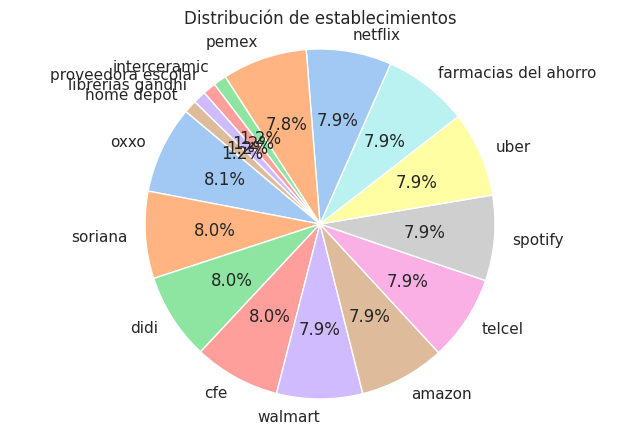

In [112]:
distribucion_negocios = transacciones_ok['nombre_comercio'].value_counts()

sns.set_style("whitegrid")

plt.figure(figsize=(8, 5))
plt.pie(distribucion_negocios,
        labels=distribucion_negocios.index,
        autopct='%1.1f%%',
        startangle=140,
        colors=sns.color_palette('pastel'))

plt.title('Distribución de establecimientos')
plt.axis('equal')
plt.show()

## 5.1 Análisis univariante

Se examinan individualmente variables numéricas y categóricas para identificar su distribución, concentración y posibles valores extremos.

### Selección de variables numéricas

Se identifican las columnas numéricas de `df_final` y se excluyen las variables identificadoras para concentrar el análisis en variables cuantitativas con significado analítico.

In [113]:
#Seleccion de variables numericas
columnas_numericas = df_final.select_dtypes(include=['int64','float64']).columns.tolist()
#Excluir variables ID
columnas_numericas = [col for col in columnas_numericas if col not in ['transaction_id','user_id']]

### Histogramas de variables numéricas

Se genera un histograma para cada variable numérica seleccionada. Los histogramas permiten observar la forma de las distribuciones y la concentración de las observaciones.

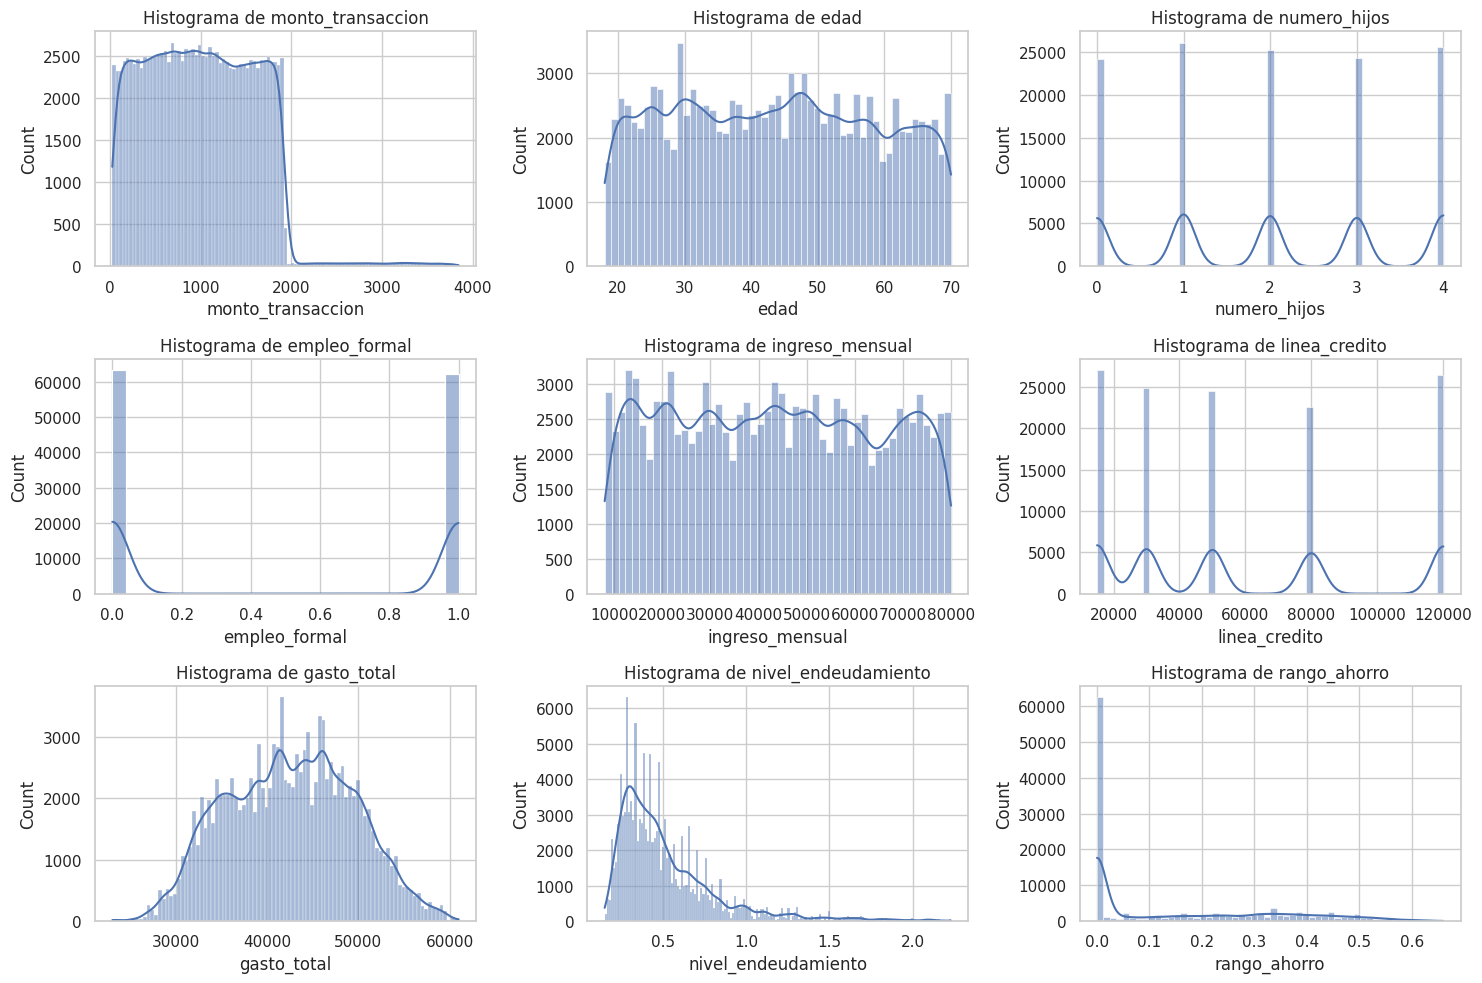

In [114]:
#histograma para cada variable
plt.figure(figsize=(15, 10))
for i, col in enumerate(columnas_numericas, 1):
    plt.subplot(3, 3, i)
    sns.histplot(df_final[col], kde=True)
    plt.title(f'Histograma de {col}')
plt.tight_layout()
plt.show()

### Detección visual de valores atípicos

Se generan diagramas de caja para las variables numéricas seleccionadas. Los boxplots permiten observar dispersión, mediana y posibles valores extremos.

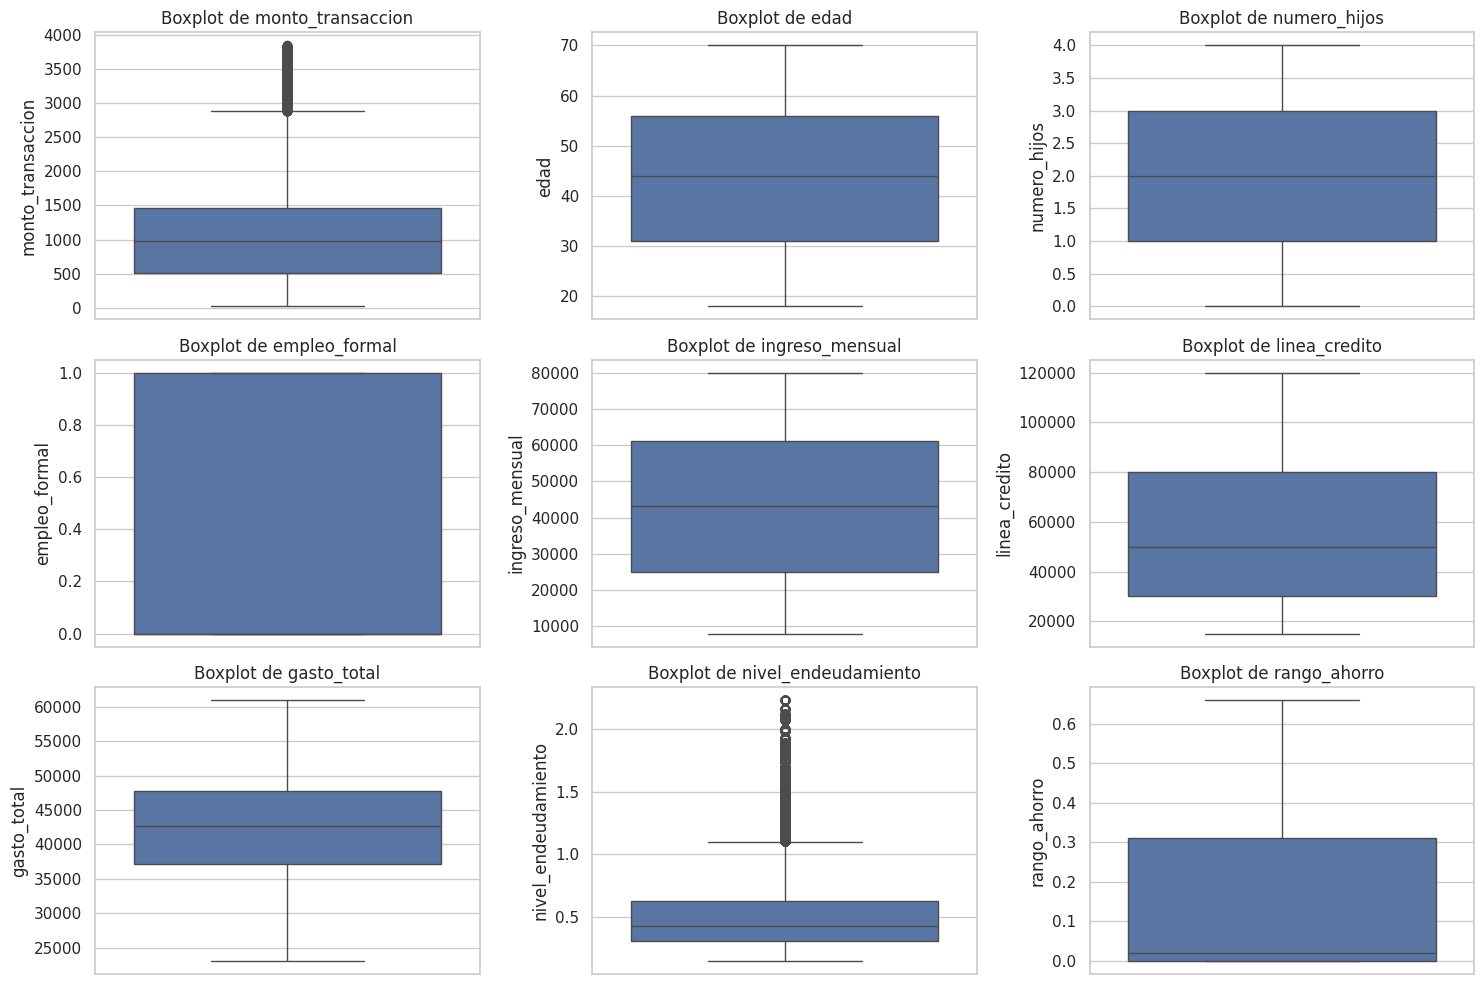

In [115]:
#Grafico de cajas para outliers
plt.figure(figsize=(15, 10))
for i, col in enumerate(columnas_numericas, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=df_final[col])
    plt.title(f'Boxplot de {col}')
    plt.tight_layout()
plt.show()

### Selección de variables categóricas

Se identifican las variables de tipo `object`, `bool` o `category` y se excluyen identificadores y descripciones que no se consideran apropiados para esta visualización.

In [116]:
# 1. Tu selección de variables (filtrando IDs y descripciones para cuidar el rendimiento)
columnas_categoricas = df_final.select_dtypes(include=['object', 'bool', 'category']).columns.tolist()
columnas_categoricas = [col for col in columnas_categoricas if col not in ['fecha_transaccion', 'nombre_comercio', 'user_id', 'transaccion_id']]

### Distribución de variables categóricas

Se genera un gráfico de barras para cada variable categórica. En cada caso se muestran como máximo las diez categorías con mayor frecuencia.

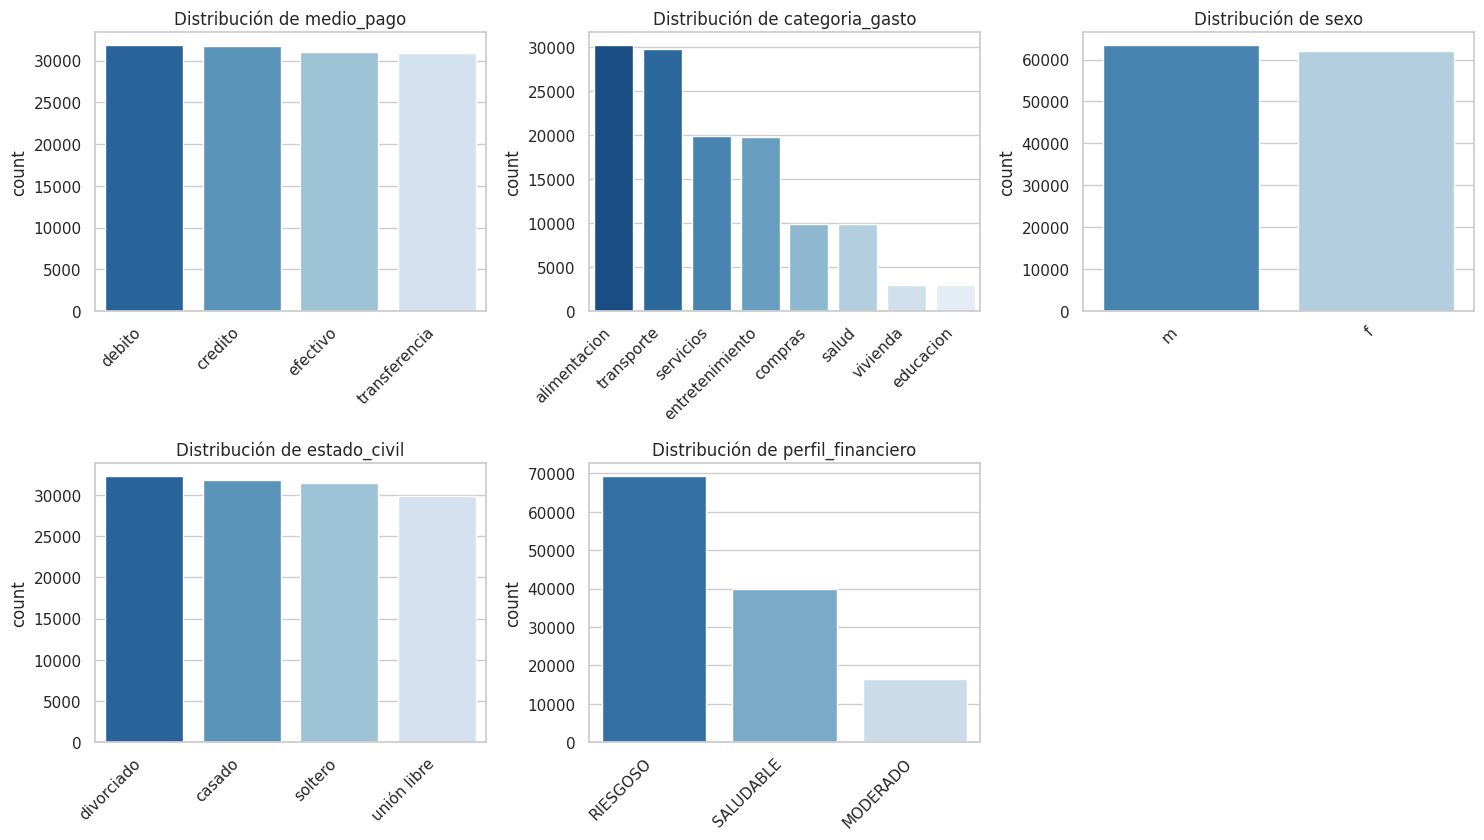

In [117]:
plt.figure(figsize=(15, 12))
for i, col in enumerate(columnas_categoricas, 1):
    plt.subplot(3, 3, i)
    order = df_final[col].value_counts().head(10).index
    sns.countplot(data=df_final, x=col, order=order, palette='Blues_r')
    plt.title(f'Distribución de {col}')
    plt.xticks(rotation=45, ha='right')
    plt.xlabel('')
    plt.tight_layout()
plt.show()

### Tablas de frecuencia

Para cada variable categórica se calcula la frecuencia relativa de sus categorías y se expresa como porcentaje. Esto permite complementar las gráficas con valores numéricos de distribución.

In [118]:
# Tabla de frecuencia
for col in columnas_categoricas:
    print(f"Tabla de frecuencia para {col}:")

    frequencia_tabla = df_final[col].value_counts(normalize = True).mul(100).round(2)

    print(frequencia_tabla)

Tabla de frecuencia para medio_pago:
medio_pago
debito           25.38
credito          25.27
efectivo         24.71
transferencia    24.64
Name: proportion, dtype: float64
Tabla de frecuencia para categoria_gasto:
categoria_gasto
alimentacion       24.08
transporte         23.73
servicios          15.87
entretenimiento    15.75
compras             7.92
salud               7.87
vivienda            2.39
educacion           2.39
Name: proportion, dtype: float64
Tabla de frecuencia para sexo:
sexo
m    50.52
f    49.48
Name: proportion, dtype: float64
Tabla de frecuencia para estado_civil:
estado_civil
divorciado     25.72
casado         25.33
soltero        25.10
unión libre    23.85
Name: proportion, dtype: float64
Tabla de frecuencia para perfil_financiero:
perfil_financiero
RIESGOSO     55.16
SALUDABLE    31.77
MODERADO     13.06
Name: proportion, dtype: float64


### Monto transaccionado por día

Se agrupan las transacciones por `fecha_transaccion` y se suma `monto_transaccion` para cada fecha. El resultado se representa mediante una serie temporal diaria.

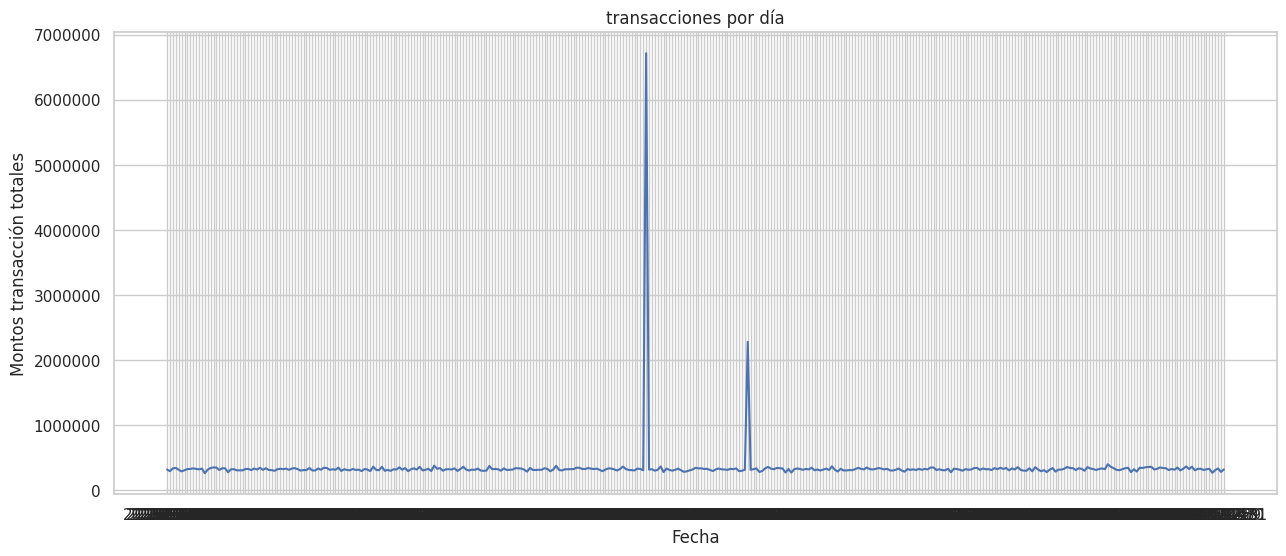

In [119]:
#transacciones por dia
plt.figure(figsize=(15,6))
ventas_por_dia = df_final.groupby('fecha_transaccion')['monto_transaccion'].sum().reset_index()
plt.plot(ventas_por_dia['fecha_transaccion'],ventas_por_dia['monto_transaccion'])
plt.title('transacciones por día')
plt.xlabel('Fecha')
plt.ylabel('Montos transacción totales')
plt.ticklabel_format(style='plain', axis='y')
plt.show()

### Agregación mensual

La fecha se convierte a formato datetime y las transacciones se agrupan por mes. Para facilitar su representación gráfica, el periodo mensual se convierte posteriormente a texto.

In [120]:
df_final['fecha_transaccion'] = pd.to_datetime(df_final['fecha_transaccion'])
transacciones_por_mes = (df_final.groupby(df_final['fecha_transaccion'].dt.to_period('M'))['monto_transaccion'].sum().reset_index())
# Convertir el periodo a texto para que Matplotlib lo grafique bien
transacciones_por_mes['fecha_transaccion'] = transacciones_por_mes['fecha_transaccion'].astype(str)

### Monto total transaccionado por mes

Se representa la suma mensual de los montos transaccionados mediante una gráfica de líneas, permitiendo observar la evolución temporal del volumen monetario.

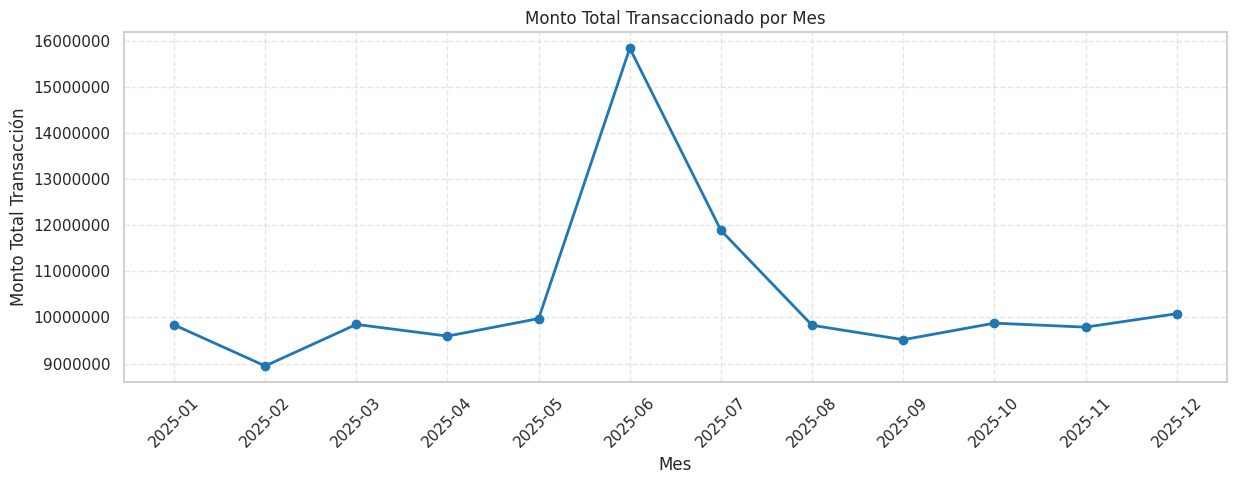

In [121]:
#  Gráfico monto transacciones por mes
plt.figure(figsize=(12, 5))
plt.plot(transacciones_por_mes['fecha_transaccion'], transacciones_por_mes['monto_transaccion'], marker='o', color='#1f77b4', linewidth=2)
plt.title('Monto Total Transaccionado por Mes')
plt.xlabel('Mes')
plt.ylabel('Monto Total Transacción')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.ticklabel_format(style='plain', axis='y')
plt.show()

### Agregación por día de la semana

Se agrupan los montos transaccionados según el día de la semana y se crea una variable textual que transforma los códigos numéricos de lunes a domingo en sus nombres correspondientes.

In [122]:
transacciones_por_dia_semana = (df_final.groupby(df_final['fecha_transaccion'].dt.dayofweek)['monto_transaccion'].sum().reset_index())
dias_semana = {0: 'Lunes', 1: 'Martes', 2: 'Miércoles', 3: 'Jueves', 4: 'Viernes', 5: 'Sábado', 6: 'Domingo'}
transacciones_por_dia_semana['dia_nombre'] = transacciones_por_dia_semana['fecha_transaccion'].map(dias_semana)

### Monto total por día de la semana

Se representa mediante barras el monto total transaccionado para cada día de la semana, con el propósito de identificar patrones semanales de actividad.

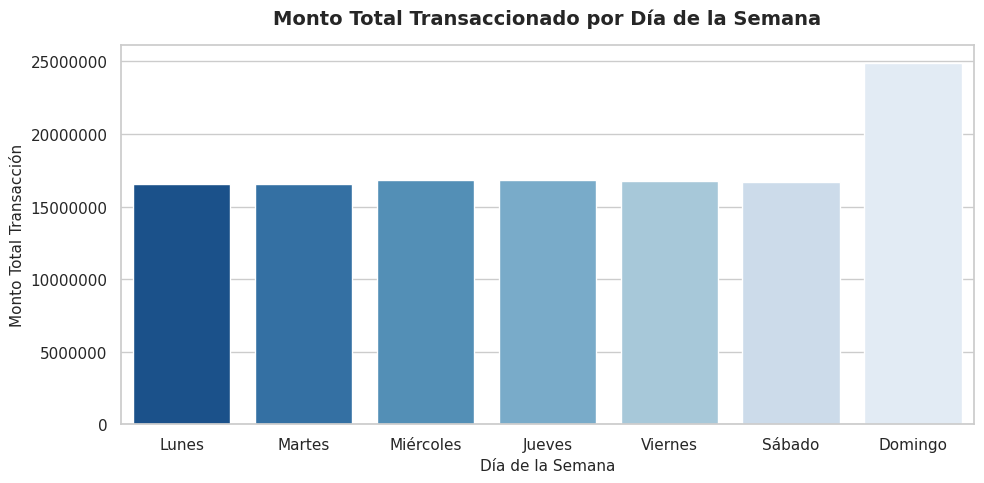

In [123]:
plt.figure(figsize=(10, 5))
sns.barplot(data=transacciones_por_dia_semana, x='dia_nombre', y='monto_transaccion', palette='Blues_r')
plt.title('Monto Total Transaccionado por Día de la Semana', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Día de la Semana', fontsize=11)
plt.ylabel('Monto Total Transacción', fontsize=11)
plt.xticks(rotation=0)
plt.ticklabel_format(style='plain', axis='y')
plt.tight_layout()
plt.show()

## 5.2 Análisis bivariante

Esta sección estudia relaciones entre pares de variables, combinando correlaciones, gráficos de dispersión, comparaciones entre variables numéricas y tablas de contingencia para variables categóricas.

### Correlación de Spearman

Se calcula una matriz de correlación de Spearman para las variables numéricas. Esta medida permite evaluar la asociación monotónica entre pares de variables y se representa mediante un mapa de calor.

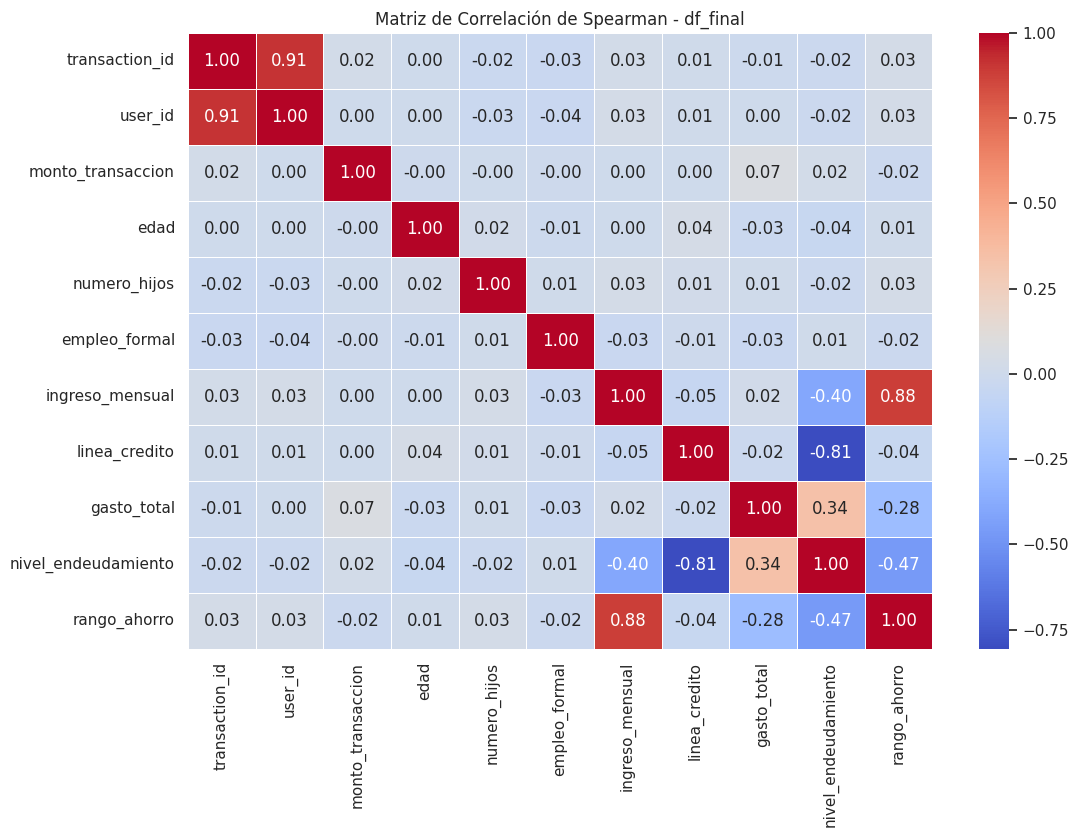

In [124]:
#Matriz de correlación entre variables usando Spearman
columnas_numericas = df_final.select_dtypes(include=['float64', 'int64'])
# Calculamos la matriz de correlación de Spearman
corr_matrix = columnas_numericas.corr(method='spearman')
# Configuramos el estilo visual
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matriz de Correlación de Spearman - df_final')
plt.show()


### Matriz de correlación de variables numéricas

Se calcula una segunda matriz de correlación para las variables numéricas y se aplica una máscara triangular para mostrar únicamente una mitad de la matriz. Los valores de correlación se presentan en un mapa de calor.

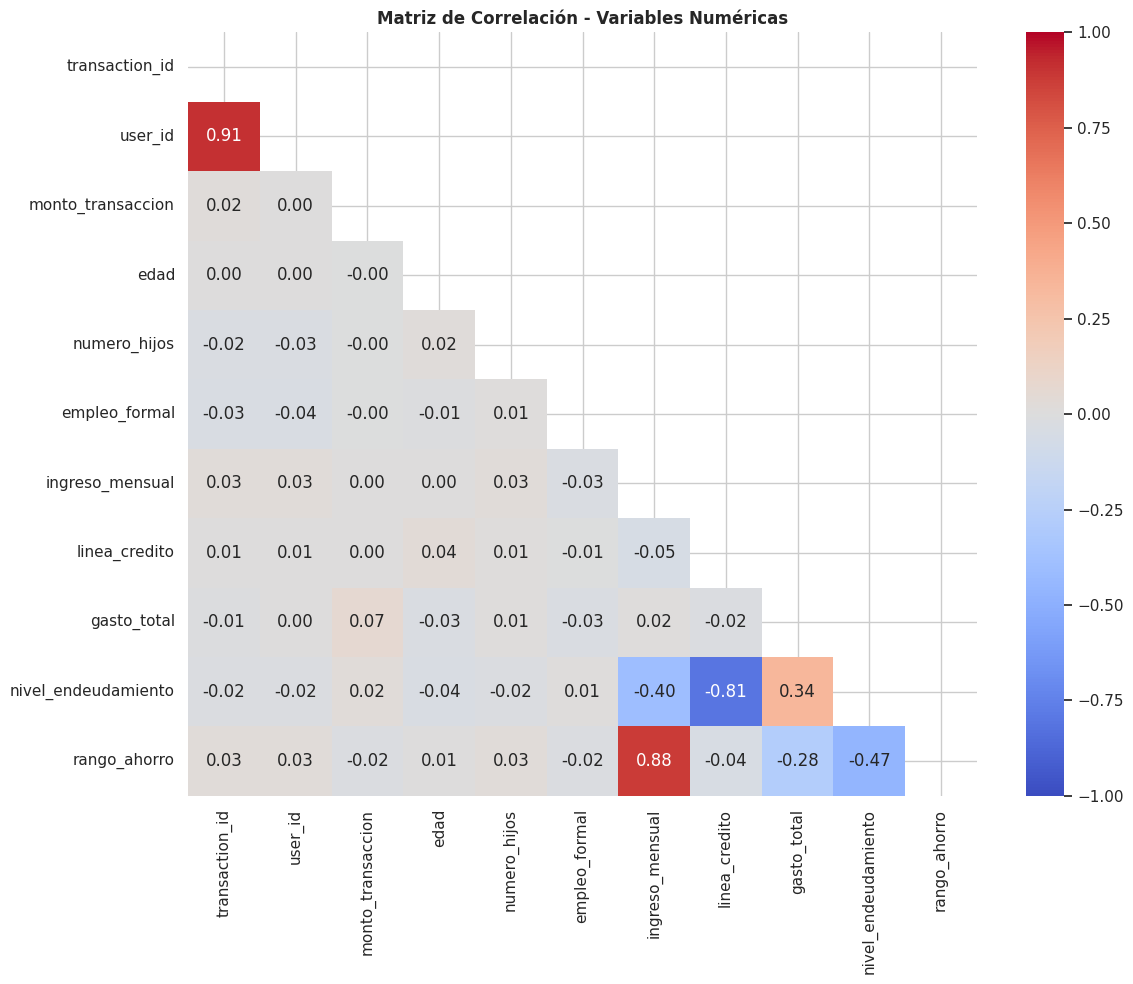

In [140]:
plt.figure(figsize=(12, 10))

columnas_numericas = df_final.select_dtypes(include='number').columns

# 1. Calcular matriz de correlación
corr = df_final[columnas_numericas].corr(method="spearman")

# 2. Crear la máscara booleana respetando la estructura de corr
mask = np.triu(np.ones_like(corr, dtype=bool))

# 3. Dibujar el mapa de calor
sns.heatmap(corr, mask=mask, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Matriz de Correlación - Variables Numéricas', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### Relaciones entre ingreso y variables financieras

Se construyen cinco gráficos de dispersión para comparar `ingreso_mensual` con `gasto_total`, `nivel_endeudamiento`, `rango_ahorro`, `empleo_formal` y `edad`.

La celda conserva los nombres de variables exactamente como aparecen en el código.

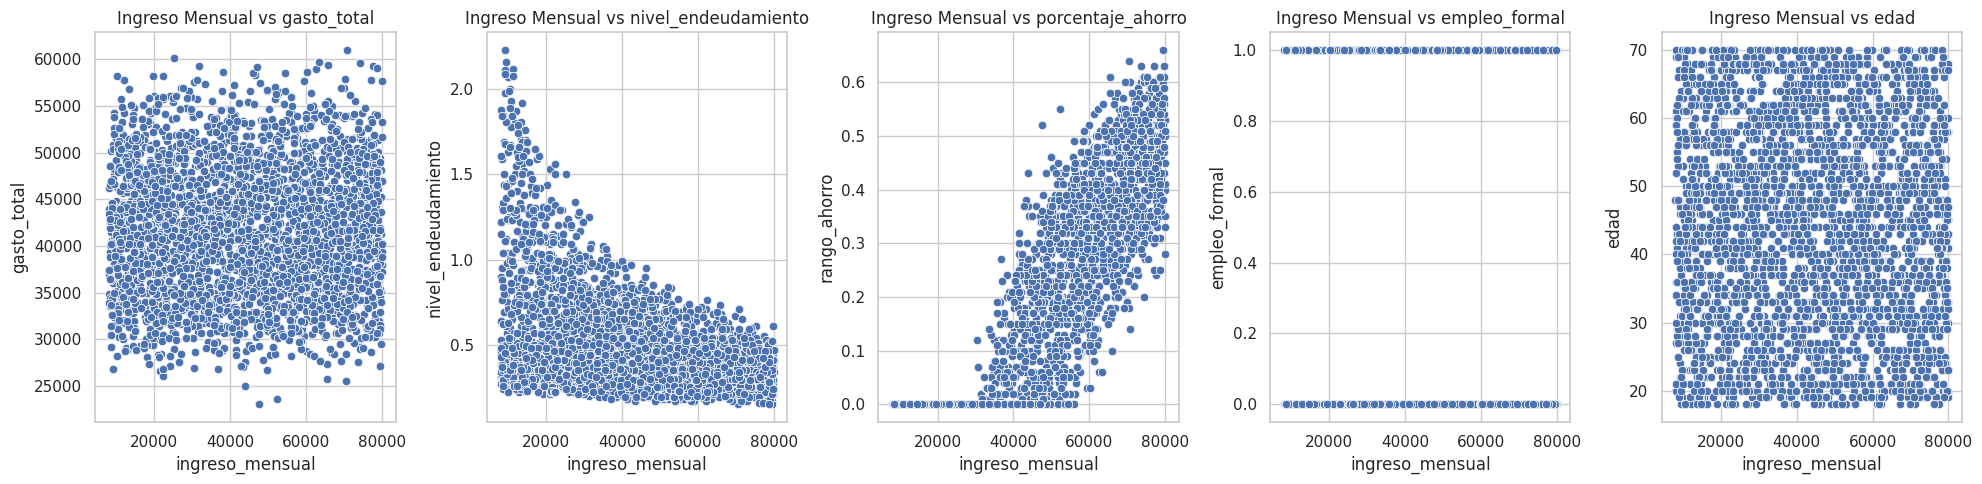

In [142]:
# Comparación de pares de Variable Principal con ingreso mensual
plt.figure(figsize=(20, 5))
plt.subplot(1,5,1)
sns.scatterplot(data=df_final,x='ingreso_mensual',y='gasto_total')
plt.title('Ingreso Mensual vs gasto_total')


plt.subplot(1,5,2)
sns.scatterplot(data=df_final,x='ingreso_mensual',y='nivel_endeudamiento')
plt.title('Ingreso Mensual vs nivel_endeudamiento')

plt.subplot(1,5,3)
sns.scatterplot(data=df_final,x='ingreso_mensual',y='rango_ahorro')
plt.title('Ingreso Mensual vs porcentaje_ahorro')

plt.subplot(1,5,4)
sns.scatterplot(data=df_final,x='ingreso_mensual',y='empleo_formal')
plt.title('Ingreso Mensual vs empleo_formal')

plt.subplot(1,5,5)
sns.scatterplot(data=df_final,x='ingreso_mensual',y='edad')
plt.title('Ingreso Mensual vs edad')
plt.tight_layout()
plt.show()

### Comparación de pares de variables numéricas

Se utiliza `pairplot` para visualizar simultáneamente las relaciones entre las variables numéricas seleccionadas, facilitando la identificación visual de patrones, asociaciones y dispersiones.

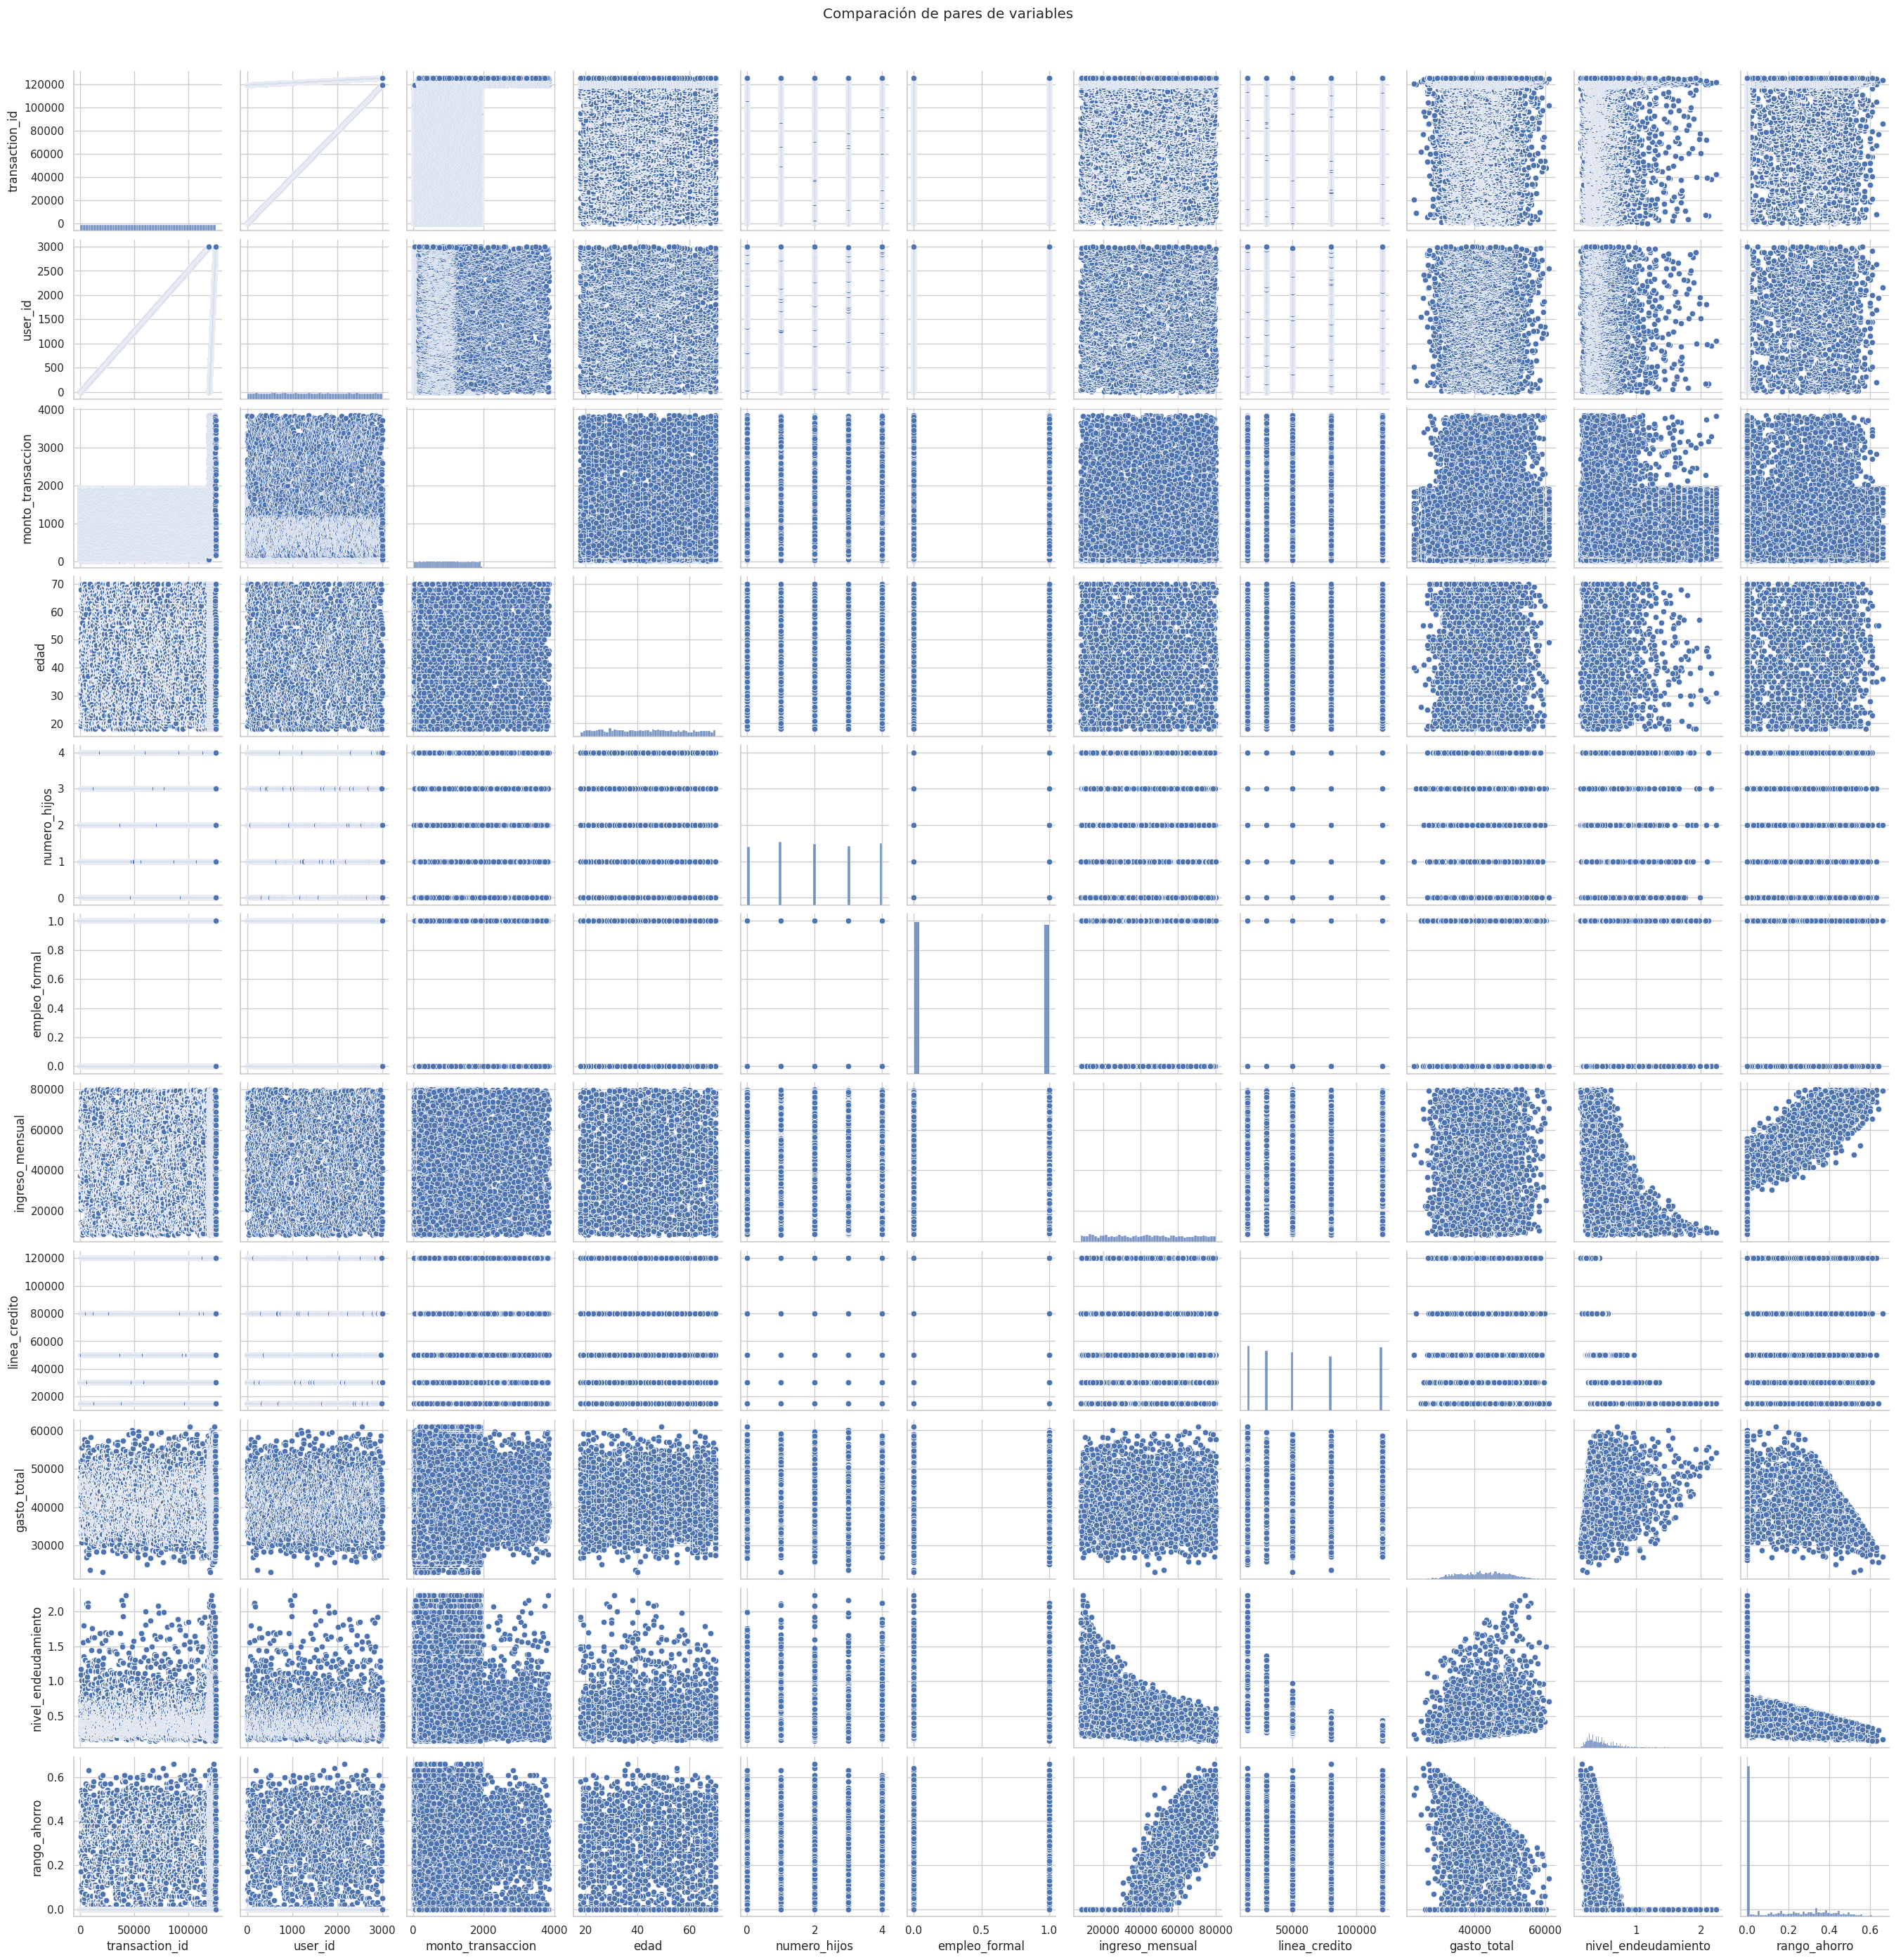

In [127]:
# Comparación de con todas variables
sns.pairplot(df_final[columnas_numericas], height=2.5)
plt.suptitle('Comparación de pares de variables', y=1.02)
plt.show()

### Relación entre variables categóricas

Se construyen tablas de contingencia normalizadas por filas para estudiar las relaciones entre `categoria_gasto` y `medio_pago`, y entre `medio_pago` y `perfil_financiero`.

Los resultados se muestran como porcentajes y también mediante mapas de calor.


Tabla de contingencia entre categoria_gasto y medio_pago (%):
medio_pago       credito  debito  efectivo  transferencia
categoria_gasto                                          
alimentacion       24.90   24.90     25.33          24.87
compras            25.38   24.60     24.74          25.28
educacion          33.20   34.50     32.30           0.00
entretenimiento    24.80   24.77     25.18          25.25
salud              25.12   25.30     24.60          24.98
servicios          24.81   25.13     24.95          25.11
transporte         24.73   25.05     25.37          24.85
vivienda           32.90   32.67      0.00          34.43


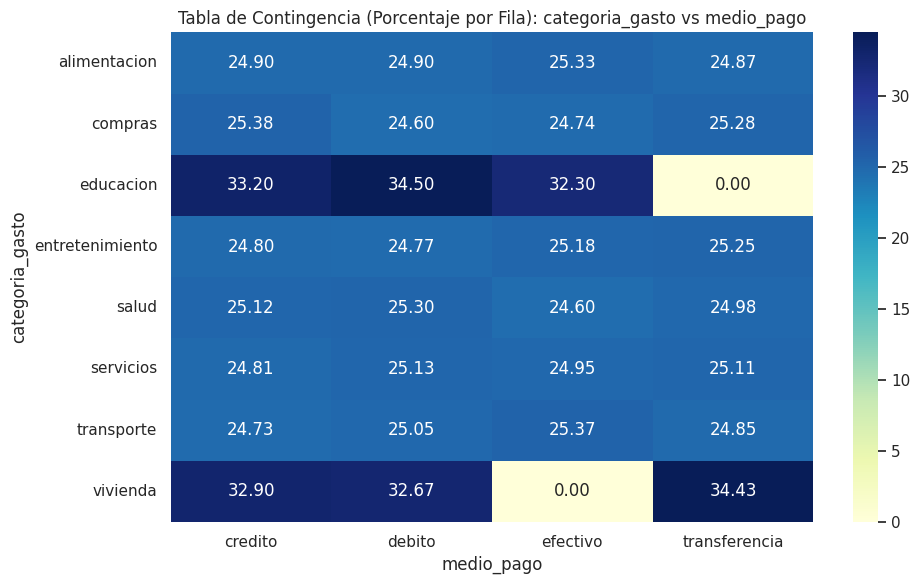


Tabla de contingencia entre medio_pago y perfil_financiero (%):
perfil_financiero  MODERADO  RIESGOSO  SALUDABLE
medio_pago                                      
credito               13.46     54.97      31.57
debito                12.98     55.30      31.71
efectivo              13.09     55.33      31.58
transferencia         12.72     55.04      32.24


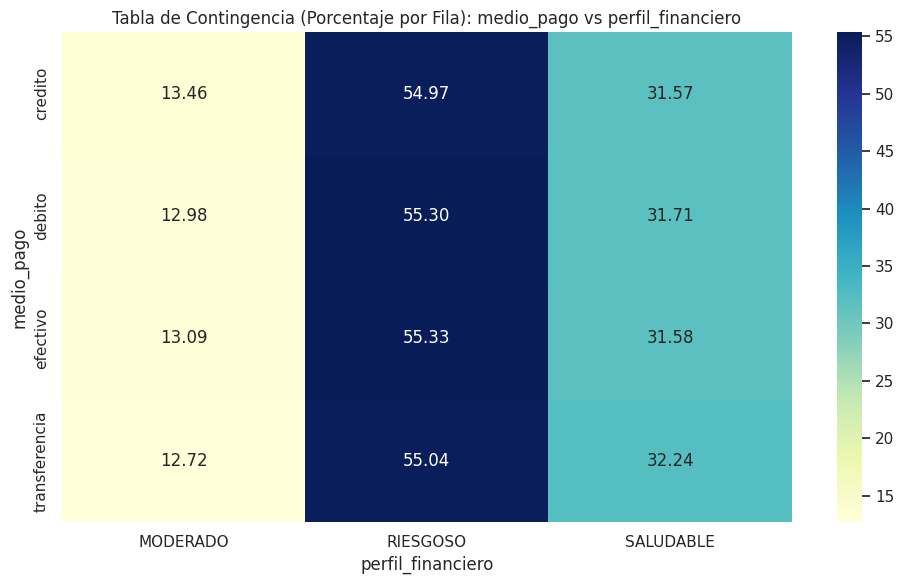

In [128]:
cat_cat_pairs = [
    ('categoria_gasto', 'medio_pago'),
    ('medio_pago', 'perfil_financiero')
]

for cat1, cat2 in cat_cat_pairs:
    # Tabla de contingencia normalizada por filas (0 a 1)
    contingency = pd.crosstab(df_final[cat1], df_final[cat2], normalize='index')

    # Imprimir en consola en escala 0-100%
    print(f"\nTabla de contingencia entre {cat1} y {cat2} (%):")
    print((contingency * 100).round(2))

    # Mapa de calor (Heatmap)
    plt.figure(figsize=(10, 6))
    # Usamos (contingency * 100) y fmt=".2f" para mostrar valores como "25.50"
    sns.heatmap(contingency * 100, annot=True, fmt=".2f", cmap="YlGnBu")
    plt.title(f"Tabla de Contingencia (Porcentaje por Fila): {cat1} vs {cat2}")
    plt.xlabel(cat2)
    plt.ylabel(cat1)
    plt.tight_layout()
    plt.show()

## 5.3 Análisis multivariable

Esta sección observa simultáneamente varias variables para explorar cómo se comportan las variables financieras y las categorías de gasto en conjunto.

### Variables clave y categoría de gasto

Se seleccionan `monto_transaccion`, `ingreso_mensual` y `linea_credito`, y se utiliza una muestra aleatoria de 3,000 registros. El `pairplot` diferencia las observaciones mediante `categoria_gasto` para facilitar la comparación visual entre categorías.

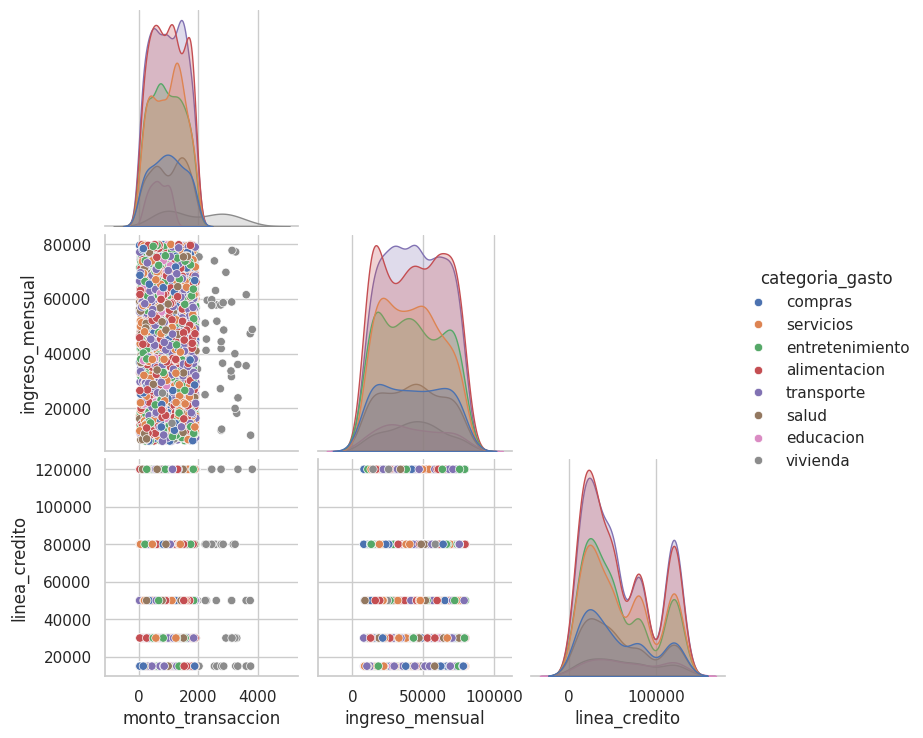

In [129]:
# Seleccionar solo variables clave
vars_clave = ['monto_transaccion', 'ingreso_mensual', 'linea_credito']
sns.pairplot(data=df_final.sample(3000)[vars_clave + ['categoria_gasto']], hue='categoria_gasto', corner=True)
plt.show()

## 6. Entrenamiento de transacciones mediante NLP

Esta etapa desarrolla el modelo de clasificación de categorías de gasto a partir del nombre del comercio y del monto de la transacción. Se comparan tres algoritmos de clasificación y se selecciona el mejor con base en F1 macro.

### Modelo A: clasificación de transacciones

Se prepara `transacciones_ok`, se eliminan duplicados y se conservan las categorías con al menos dos observaciones.

Las variables predictoras son `nombre_comercio` y `monto_transaccion`, mientras que `categoria_gasto` es la variable objetivo. El texto se transforma mediante TF-IDF y el monto se estandariza mediante `StandardScaler`.

Se comparan tres clasificadores: **Logistic Regression, Linear SVC y Random Forest**. Para cada uno se calculan Accuracy de entrenamiento y prueba, Precision Macro, Recall Macro y F1-Score Macro. El modelo con mayor F1 Macro en el conjunto de prueba se conserva como `best_pipeline`.

Finalmente se genera un reporte de clasificación y una matriz de confusión para el mejor modelo.

📊 Filas iniciales en transacciones_ok: 125465
📋 Columnas disponibles: ['transaction_id', 'user_id', 'fecha_transaccion', 'nombre_comercio', 'monto_transaccion', 'medio_pago', 'categoria_gasto']
📊 Filas después de limpiar duplicados: 125465
📊 Filas finales antes del split: 125465
✅ Filas de entrenamiento: 100372
✅ Filas de prueba (Test): 25093

🚀 Entrenando modelos con el volumen completo...


,Modelo,Acc Train,Acc Test,Precision Macro,Recall Macro,F1-Score Macro
0,Logistic Regression,1.0,1.0,1.0,1.0,1.0
1,Linear SVC,1.0,1.0,1.0,1.0,1.0
2,Random Forest,1.0,1.0,1.0,1.0,1.0



--- MEJOR MODELO SELECCIONADO: Logistic Regression ---

Classification Report:
                 precision    recall  f1-score   support

   alimentacion       1.00      1.00      1.00      6042
        compras       1.00      1.00      1.00      1987
      educacion       1.00      1.00      1.00       600
entretenimiento       1.00      1.00      1.00      3953
          salud       1.00      1.00      1.00      1975
      servicios       1.00      1.00      1.00      3981
     transporte       1.00      1.00      1.00      5955
       vivienda       1.00      1.00      1.00       600

       accuracy                           1.00     25093
      macro avg       1.00      1.00      1.00     25093
   weighted avg       1.00      1.00      1.00     25093



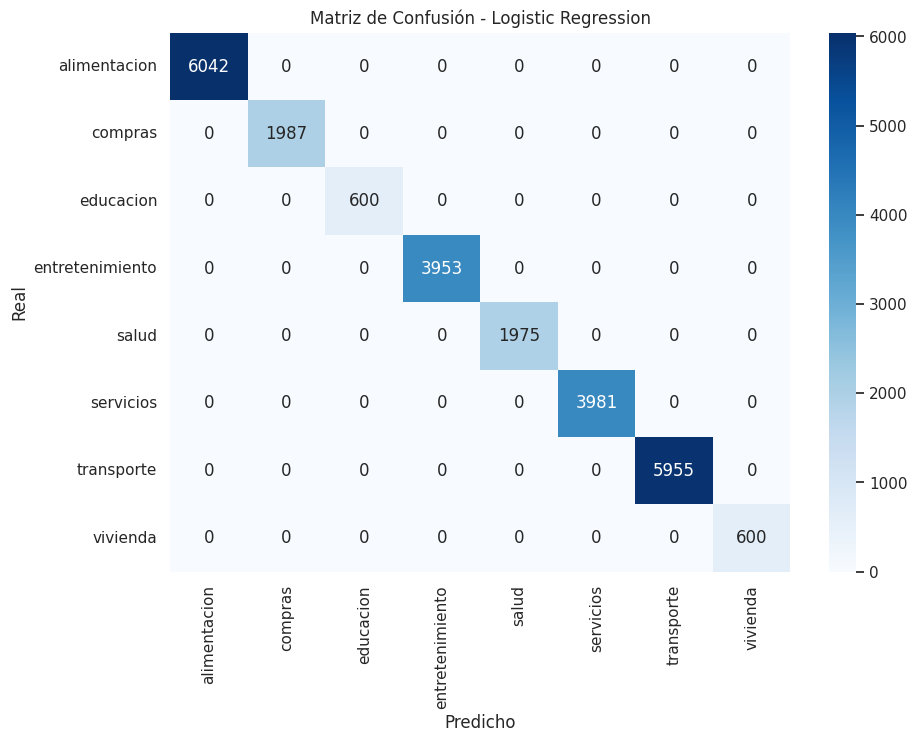


✅ Pipeline exportado exitosamente como 'modelo_clasificacion_transacciones.pkl'


In [130]:
import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, precision_score, recall_score
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 0. VERIFICAR EL ESTADO INICIAL
# ==========================================
print(f"📊 Filas iniciales en transacciones_ok: {len(transacciones_ok)}")
print(f"📋 Columnas disponibles: {list(transacciones_ok.columns)}")

# ==========================================
# 1. LIMPIEZA Y FILTRADO DE DATOS
# ==========================================
transacciones_ok['nombre_comercio'] = transacciones_ok['nombre_comercio'].astype(str).str.lower().str.strip()
transacciones_ok = transacciones_ok.drop_duplicates()

print(f"📊 Filas después de limpiar duplicados: {len(transacciones_ok)}")

# (Opcional) Si quieres relajar el filtro temporalmente para que no borre todo,
# cambia el '10' por '2' para asegurarnos de que pasen datos.
conteo_clases = transacciones_ok['categoria_gasto'].value_counts()
categorias_validas = conteo_clases[conteo_clases >= 2].index # 👈 Bajamos a 2 para probar
transacciones_ok = transacciones_ok[transacciones_ok['categoria_gasto'].isin(categorias_validas)]

print(f"📊 Filas finales antes del split: {len(transacciones_ok)}")

# ==========================================
# 2. SEPARAR VARIABLES
# ==========================================
X = transacciones_ok[['nombre_comercio', 'monto_transaccion']]
y = transacciones_ok['categoria_gasto']

# ==========================================
# 3. DIVISIÓN ESTÁNDAR (20% para prueba)
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"✅ Filas de entrenamiento: {X_train.shape[0]}")
print(f"✅ Filas de prueba (Test): {X_test.shape[0]}")

# ==========================================
# 4. PREPROCESAMIENTO: ColumnTransformer
# ==========================================
preprocessor = ColumnTransformer(
    transformers=[
        ('tfidf', TfidfVectorizer(token_pattern=r"(?u)\b\w+\b", max_features=5000, min_df=2), 'nombre_comercio'),
        ('scaler', StandardScaler(), ['monto_transaccion'])
    ]
)

# ==========================================
# 5. DEFINICIÓN DE MODELOS
# ==========================================
models = {
    'Logistic Regression': LogisticRegression(C=1.0, max_iter=1000, random_state=42),
    'Linear SVC': LinearSVC(C=1.0, random_state=42, max_iter=2000),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=25, min_samples_split=5, random_state=42, n_jobs=-1)
}

results = []
best_f1 = 0
best_model_name = ""
best_pipeline = None

# ==========================================
# 6. ENTRENAMIENTO Y EVALUACIÓN COMPARATIVA
# ==========================================
print("\n🚀 Entrenando modelos con el volumen completo...")
for name, model in models.items():
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])

    # Entrenar
    pipeline.fit(X_train, y_train)

    # Predecir
    y_pred_train = pipeline.predict(X_train)
    y_pred_test = pipeline.predict(X_test)

    # Métricas
    acc_train = accuracy_score(y_train, y_pred_train)
    acc_test = accuracy_score(y_test, y_pred_test)
    f1 = f1_score(y_test, y_pred_test, average='macro', zero_division=0)
    precision = precision_score(y_test, y_pred_test, average='macro', zero_division=0)
    recall = recall_score(y_test, y_pred_test, average='macro', zero_division=0)

    results.append({
        'Modelo': name,
        'Acc Train': acc_train,
        'Acc Test': acc_test,
        'Precision Macro': precision,
        'Recall Macro': recall,
        'F1-Score Macro': f1
    })

    # Selección del mejor modelo basado en F1-Score Macro
    if f1 > best_f1:
        best_f1 = f1
        best_model_name = name
        best_pipeline = pipeline

# ==========================================
# 7. MOSTRAR TABLA COMPARATIVA
# ==========================================
df_results = pd.DataFrame(results)
display(df_results.sort_values(by='F1-Score Macro', ascending=False))

# ==========================================
# 8. EVALUACIÓN DETALLADA DEL MEJOR MODELO
# ==========================================
print(f"\n--- MEJOR MODELO SELECCIONADO: {best_model_name} ---")
y_final_pred = best_pipeline.predict(X_test)
print("\nClassification Report:")
print(classification_report(y_test, y_final_pred, zero_division=0))

# Matriz de Confusión
plt.figure(figsize=(10, 7))
cm = confusion_matrix(y_test, y_final_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=best_pipeline.classes_,
            yticklabels=best_pipeline.classes_)
plt.title(f'Matriz de Confusión - {best_model_name}')
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.show()

# ==========================================
# 9. SERIALIZACIÓN DEL PIPELINE
# ==========================================
joblib.dump(best_pipeline, 'modelo_clasificacion_transacciones.pkl')
print(f"\n✅ Pipeline exportado exitosamente como 'modelo_clasificacion_transacciones.pkl'")

### Prueba del clasificador de transacciones

Se crea una transacción de prueba con un nombre de comercio y un monto inventados. El `best_pipeline` genera una categoría para esa nueva observación, permitiendo comprobar el funcionamiento del modelo fuera de las observaciones utilizadas durante el entrenamiento.

In [131]:
# Prueba rápida con un comercio inventado
cliente_nuevo = pd.DataFrame({
    'nombre_comercio': ['supermercado central wong'],  # Inventa un nombre
    'monto_transaccion': [150.50]                      # Inventa un monto
})

prediccion = best_pipeline.predict(cliente_nuevo)
print(f"Categoría predicha: {prediccion[0]}")

Categoría predicha: alimentacion


## 7. Entrenamiento del perfil financiero

Esta etapa construye un modelo de clasificación para asignar a cada cliente uno de los perfiles financieros definidos previamente: SALUDABLE, MODERADO o RIESGOSO.

El modelo utiliza nueve variables, combinando características demográficas, laborales, financieras y el indicador `rango_ahorro`.

### Modelo B: clasificación del perfil financiero

Se recalcula `rango_ahorro` y se definen nueve variables de entrada: `edad`, `sexo`, `estado_civil`, `numero_hijos`, `empleo_formal`, `ingreso_mensual`, `linea_credito`, `nivel_endeudamiento` y `rango_ahorro`.

Las variables numéricas se estandarizan y las categóricas se transforman mediante `OneHotEncoder`. Sobre este preprocesamiento se utiliza un `RandomForestClassifier`.

Los hiperparámetros se optimizan mediante `RandomizedSearchCV` con validación cruzada de cinco particiones y F1 Macro como criterio de selección. El mejor modelo se evalúa mediante Accuracy, F1 Macro, Precision Macro, Recall Macro, reporte de clasificación y matriz de confusión.

🚀 Entrenando Modelo B...

Mejores Hiperparámetros: {'classifier__n_estimators': 300, 'classifier__min_samples_split': 5, 'classifier__min_samples_leaf': 4, 'classifier__max_features': 'log2', 'classifier__max_depth': 20}

--- Métricas de Evaluación ---
Accuracy: 1.0000
F1-Score Macro: 1.0000
Precision Macro: 1.0000
Recall Macro: 1.0000

Classification Report:
              precision    recall  f1-score   support

    MODERADO       1.00      1.00      1.00        76
    RIESGOSO       1.00      1.00      1.00       323
   SALUDABLE       1.00      1.00      1.00       201

    accuracy                           1.00       600
   macro avg       1.00      1.00      1.00       600
weighted avg       1.00      1.00      1.00       600



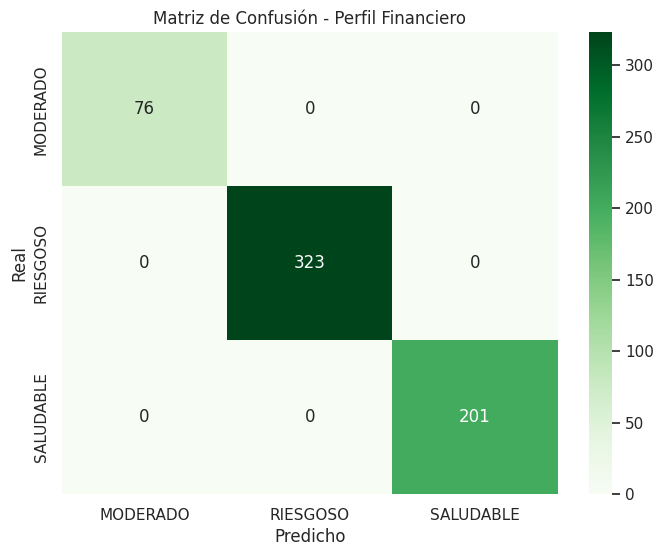

In [132]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, precision_score, recall_score

# ==========================================
# 1. CÁLCULO DE 'rango_ahorro' CON TU FÓRMULA EXACTA
# ==========================================
# (Asegúrate de que tu DataFrame 'clientes' tenga 'gasto_total' o cámbialo por la suma de tus transacciones históricas)
pct_ahorro_calc = (
    (clientes["ingreso_mensual"] - clientes["gasto_total"]).clip(lower=0)
    / clientes["ingreso_mensual"]
)
clientes["rango_ahorro"] = pct_ahorro_calc.replace([np.inf, -np.inf], 0).fillna(0).round(4)

# ==========================================
# 2. DEFINICIÓN DE LAS 9 COLUMNAS
# ==========================================
columnas_backend = [
    'edad',
    'sexo',
    'estado_civil',
    'numero_hijos',
    'empleo_formal',
    'ingreso_mensual',
    'linea_credito',
    'nivel_endeudamiento',
    'rango_ahorro'  # Entra como el valor numérico único calculado por fórmula
]

X = clientes[columnas_backend]
y = clientes['perfil_financiero']

# ==========================================
# 3. SEPARACIÓN DE VARIABLES
# ==========================================
numeric_features = [
    'edad',
    'numero_hijos',
    'empleo_formal',
    'ingreso_mensual',
    'linea_credito',
    'nivel_endeudamiento',
    'rango_ahorro'  # Va directo a las numéricas escaladas
]
categorical_features = ['sexo', 'estado_civil']  # Únicas categóricas con OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

# ==========================================
# 4. DIVISIÓN Y OPTIMIZACIÓN
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

param_dist = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [None, 10, 20],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4],
    'classifier__max_features': ['sqrt', 'log2']
}

random_search = RandomizedSearchCV(
    rf_pipeline,
    param_distributions=param_dist,
    n_iter=15,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    random_state=42
)

print("🚀 Entrenando Modelo B...")
random_search.fit(X_train, y_train)
best_model = random_search.best_estimator_

# ==========================================
# 5. EVALUACIÓN Y MÉTRICAS
# ==========================================
y_pred = best_model.predict(X_test)

print(f"\nMejores Hiperparámetros: {random_search.best_params_}")
print("\n--- Métricas de Evaluación ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"F1-Score Macro: {f1_score(y_test, y_pred, average='macro'):.4f}")
print(f"Precision Macro: {precision_score(y_test, y_pred, average='macro'):.4f}")
print(f"Recall Macro: {recall_score(y_test, y_pred, average='macro'):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Matriz de Confusión
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Greens',
            xticklabels=best_model.classes_, yticklabels=best_model.classes_)
plt.title('Matriz de Confusión - Perfil Financiero')
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.show()


### Importancia de variables y exportación del modelo

Se recuperan los nombres de las variables después del preprocesamiento, incluyendo las categorías creadas por `OneHotEncoder`, y se relacionan con las importancias producidas por Random Forest.

La función devuelve una tabla ordenada por importancia y genera una gráfica. Posteriormente el modelo seleccionado se guarda como `modelo_perfil_financiero.pkl` mediante `joblib`.

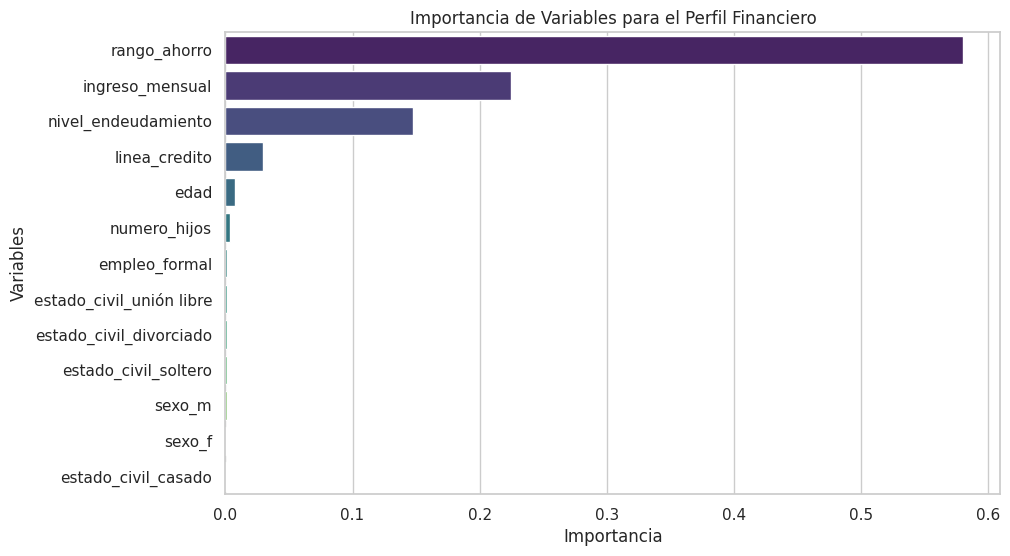


✅ ¡Modelo B exportado correctamente con 'rango_ahorro' como variable numérica única!


In [133]:

# ==========================================
# 6. IMPORTANCIA DE VARIABLES (rango_ahorro sale como una sola barra)
# ==========================================
def plot_feature_importance(model, numeric_features, categorical_features):
    ohe = model.named_steps['preprocessor'].named_transformers_['cat']
    ohe_features = ohe.get_feature_names_out(categorical_features)
    feature_names = numeric_features + ohe_features.tolist()

    importances = model.named_steps['classifier'].feature_importances_

    feature_imp = pd.DataFrame({'Variable': feature_names, 'Importancia': importances})
    feature_imp = feature_imp.sort_values(by='Importancia', ascending=False)

    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importancia', y='Variable', data=feature_imp, palette='viridis')
    plt.title('Importancia de Variables para el Perfil Financiero')
    plt.xlabel('Importancia')
    plt.ylabel('Variables')
    plt.show()

    return feature_imp

feat_imp_df = plot_feature_importance(best_model, numeric_features, categorical_features)

# ==========================================
# 7. EXPORTACIÓN
# ==========================================
joblib.dump(best_model, 'modelo_perfil_financiero.pkl')
print("\n✅ ¡Modelo B exportado correctamente con 'rango_ahorro' como variable numérica única!")

### Prueba del modelo de perfil financiero

Se construye un cliente de prueba con las nueve variables utilizadas por el modelo. El modelo devuelve el perfil financiero predicho y la probabilidad máxima asociada a la predicción.

In [134]:
# --- Prueba con las 9 variables exactas del Back-End ---
print("\n--- Predicción Modelo B (Perfil Financiero) ---")

cliente_prueba = pd.DataFrame([{
    'edad': 25,
    'sexo': 'f',
    'estado_civil': 'soltero',
    'numero_hijos': 0,
    'empleo_formal': 1,
    'ingreso_mensual': 20000.0,
    'linea_credito': 10000.0,
    'nivel_endeudamiento': 12.5,   # <-- Métrica calculada (ejemplo)
    'rango_ahorro': 0.45          # <-- Cambiado de 'porcentaje_ahorro' a 'rango_ahorro'
}])

prediccion_perfil = best_model.predict(cliente_prueba)[0]
probabilidades = best_model.predict_proba(cliente_prueba)[0]
probabilidad_max = round(float(max(probabilidades)), 2)

print(f"Perfil Predicho: {prediccion_perfil}")
print(f"Probabilidad: {probabilidad_max}")


--- Predicción Modelo B (Perfil Financiero) ---
Perfil Predicho: MODERADO
Probabilidad: 0.57


### Instalación de SHAP

Se instala la biblioteca `shap` para realizar el análisis de explicabilidad del modelo de perfil financiero.

In [135]:
!pip install shap -q

## 8. Análisis de impacto mediante SHAP

Se extraen el preprocesador y el clasificador del mejor Random Forest, se transforman los datos de prueba y se recuperan los nombres de las variables resultantes del One-Hot Encoding.

Posteriormente se utiliza `TreeExplainer` para obtener valores SHAP del Random Forest y se genera un `Summary Plot` de tipo barra para visualizar el impacto global de las variables en las predicciones.

Visualizando el impacto SHAP (Summary Plot):


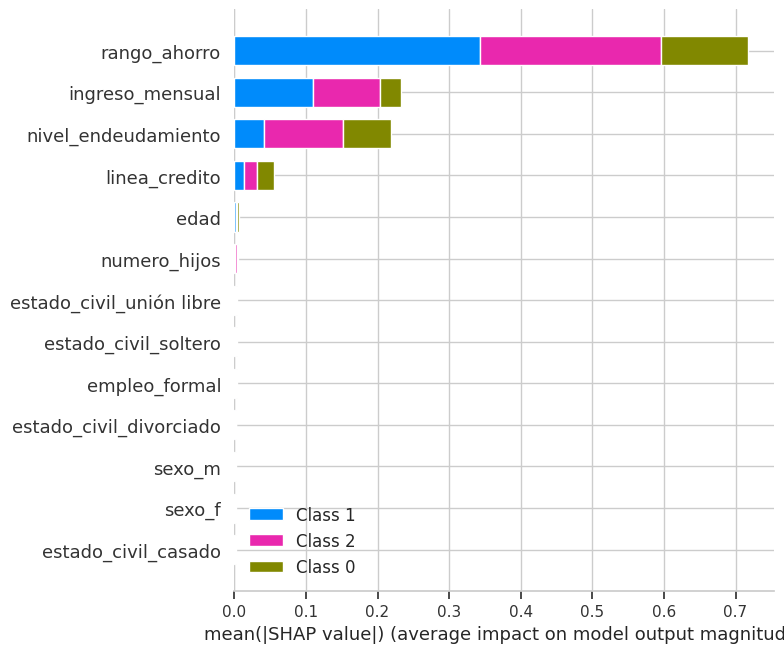

In [136]:
import shap

# 1. Preparar los datos transformados
# Extraemos el preprocesador y el clasificador del mejor modelo
preprocessor = best_model.named_steps['preprocessor']
clf = best_model.named_steps['classifier']

# Transformamos una muestra de test para el análisis (SHAP es intensivo en cómputo)
X_test_transformed = preprocessor.transform(X_test)

# Obtener nombres de las columnas transformadas para legibilidad
ohe_features = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
feature_names = numeric_features + ohe_features.tolist()

# 2. Inicializar el explicador de SHAP (TreeExplainer para Random Forest)
explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(X_test_transformed)

# 3. Visualización
# Mostramos el impacto de las variables para todas las clases
print("Visualizando el impacto SHAP (Summary Plot):")
shap.summary_plot(shap_values, X_test_transformed, feature_names=feature_names, plot_type="bar")

### Identificación de clases del modelo

Se recorren las clases reconocidas por `best_model` y se imprime la correspondencia entre el índice numérico y la etiqueta textual de cada clase.

In [137]:
for i, label in enumerate(best_model.classes_):
    print(f"Clase {i}: {label}")

Clase 0: MODERADO
Clase 1: RIESGOSO
Clase 2: SALUDABLE


### Interpretación del análisis SHAP

El notebook describe el gráfico SHAP desde dos perspectivas: la **magnitud del impacto** de las variables y su **distribución por clase**. Esta sección sirve como puente entre la salida técnica del modelo y su interpretación.

### Análisis de Impacto SHAP

El gráfico anterior nos permite entender:
1. **Magnitud**: Qué tan fuerte es el impacto de cada variable en la decisión final.
2. **Distribución por Clase**: Los colores representan cómo cada variable contribuye a las diferentes etiquetas del perfil financiero.

Generalmente, verás que `credito_utilizado` y `monto_promedio_ahorro` dominan la explicación, confirmando que el comportamiento de ahorro e ingresos es lo que más separa a un usuario saludable de uno en riesgo.

### Preparación para pruebas con datos nuevos

Esta sección introduce la fase de inferencia. Se plantea utilizar los pipelines o modelos guardados para clasificar observaciones que no forman parte del conjunto utilizado durante el entrenamiento.

### Prueba de Predicción con Datos Nuevos
En esta sección, utilizaremos los Pipelines cargados (o los objetos `best_pipeline` y `best_model` que tenemos en memoria) para clasificar datos que no estaban en el dataset original.

## 9. Prueba de predicción del modelo de transacciones

Se carga desde disco el pipeline `modelo_clasificacion_transacciones.pkl`. Después se crean tres transacciones nuevas, se normaliza el texto de `nombre_comercio` y se obtienen las categorías predichas.

La salida presenta cada descripción de transacción junto con la categoría asignada por el Modelo A.

In [138]:
import pandas as pd
import joblib

# 1. Cargar el pipeline que guardaste en disco
best_pipeline = joblib.load('modelo_clasificacion_transacciones.pkl')

# 2. Datos de prueba
nueva_transaccion = pd.DataFrame({
    'nombre_comercio': ['viaje nocturno uber', 'suscripción mensual netflix', 'compra en soriana'],
    'monto_transaccion': [250.0, 189.0, 1200.50]
})

# 3. Limpieza de texto
nueva_transaccion['nombre_comercio'] = nueva_transaccion['nombre_comercio'].astype(str).str.lower().str.strip()

# 4. Predicción
prediccion_a = best_pipeline.predict(nueva_transaccion)

print("--- Predicción Modelo A (Transacciones) ---")
for desc, cat in zip(nueva_transaccion['nombre_comercio'], prediccion_a):
    print(f"Transacción: '{desc}' -> Categoría Predicha: {cat.upper()}")

--- Predicción Modelo A (Transacciones) ---
Transacción: 'viaje nocturno uber' -> Categoría Predicha: TRANSPORTE
Transacción: 'suscripción mensual netflix' -> Categoría Predicha: ENTRETENIMIENTO
Transacción: 'compra en soriana' -> Categoría Predicha: ALIMENTACION


## 10. Pruebas finales

Esta sección realiza una prueba final del modelo de perfil financiero guardado en formato `.pkl`, utilizando clientes simulados con las nueve variables requeridas por el modelo actual.

### Prueba final del modelo de perfil financiero

Se carga `modelo_perfil_financiero.pkl` y se construyen dos clientes simulados con distintos niveles de ingreso, crédito, endeudamiento y ahorro.

El modelo genera una predicción para cada cliente y la salida muestra el perfil asignado por el archivo `.pkl`.

In [139]:
import joblib
import pandas as pd

# 1. Cargar el modelo .pkl actualizado
modelo = joblib.load('modelo_perfil_financiero.pkl')

# 2. Crear los clientes simulados con las 9 variables exactas del modelo actual
clientes_prueba = pd.DataFrame([
    {
        'edad': 28,
        'sexo': 'm',
        'estado_civil': 'soltero',
        'numero_hijos': 0,
        'empleo_formal': 1,
        'ingreso_mensual': 15000.0,
        'linea_credito': 8000.0,
        'nivel_endeudamiento': 0.06,  # 6% de endeudamiento (escala 0.0 a 1.0)
        'rango_ahorro': 0.40     # 40% de ahorro (escala 0.0 a 1.0)
    },
    {
        'edad': 45,
        'sexo': 'f',
        'estado_civil': 'casado',
        'numero_hijos': 3,
        'empleo_formal': 1,
        'ingreso_mensual': 5000.0,
        'linea_credito': 12000.0,
        'nivel_endeudamiento': 0.85,  # 85% de endeudamiento (escala 0.0 a 1.0)
        'rango_ahorro': 0.01     # 1% de ahorro (escala 0.0 a 1.0)
    }
])

# 3. Predicción
predicciones = modelo.predict(clientes_prueba)

# 4. Mostrar el resultado
for i, perfil in enumerate(predicciones):
    print(f"Cliente {i+1} -> Perfil Asignado por el .pkl: {str(perfil).upper()}")

Cliente 1 -> Perfil Asignado por el .pkl: SALUDABLE
Cliente 2 -> Perfil Asignado por el .pkl: RIESGOSO
